In [ ]:
"""
STEP 1: DATA COLLECTION AND PREPROCESSING
Complete Implementation - Literature-Backed Approach
Optimized for Kaggle with GPU Support

References:
- Forecasting high-impact research topics via ML on knowledge graphs
- Time gap analysis by topic model-based temporal technique
- Knowledge graph analysis and visualization of AI research
"""

import pandas as pd
import numpy as np
import json
import re
from datetime import datetime
from tqdm import tqdm
import requests
import time
from collections import defaultdict

print("="*80)
print("STEP 1: DATA COLLECTION AND PREPROCESSING")
print("="*80)

# ============================================================================
# 1.1 DATASET SELECTION & COLLECTION
# ============================================================================

class MultiSourceDataCollector:
    """
    Collect data from multiple sources: arXiv (Kaggle), Semantic Scholar, OpenAlex
    Following literature-backed best practices
    """
    
    def __init__(self):
        self.arxiv_data = None
        self.semantic_scholar_data = {}
        self.openalex_data = {}
        
    # -------------------------------------------------------------------------
    # arXiv Collection (via Kaggle dataset)
    # -------------------------------------------------------------------------
    
    def collect_arxiv_kaggle(self, 
                            input_file='/kaggle/input/arxiv/arxiv-metadata-oai-snapshot.json',
                            categories=['cs.AI', 'cs.LG', 'cs.CV', 'cs.CL', 'cs.NE'],
                            years=range(2019, 2025)):
        """
        Collect arXiv papers from Kaggle dataset
        Fast and complete data collection
        """
        print("\n" + "="*80)
        print("1.1 ARXIV DATA COLLECTION (KAGGLE DATASET)")
        print("="*80)
        
        target_categories = set(categories)
        target_years = set(years)
        
        papers = []
        
        # Count lines for progress
        print("Counting total papers...")
        with open(input_file, 'r') as f:
            total_lines = sum(1 for _ in f)
        print(f"Total papers in dataset: {total_lines:,}\n")
        
        print("Collecting and filtering papers...")
        with open(input_file, 'r') as f:
            for line in tqdm(f, total=total_lines, desc="Processing"):
                try:
                    paper = json.loads(line)
                    
                    # Filter by categories
                    categories_list = paper.get('categories', '').split()
                    if not any(cat in target_categories for cat in categories_list):
                        continue
                    
                    # Get original submission date
                    versions = paper.get('versions', [])
                    if not versions:
                        continue
                    
                    original_date = versions[0].get('created', '')
                    year = self._parse_year(original_date)
                    
                    if not year or year not in target_years:
                        continue
                    
                    # Extract metadata
                    abstract = paper.get('abstract', '').replace('\n', ' ').strip()
                    if len(abstract) < 50:
                        continue
                    
                    papers.append({
                        'arxiv_id': paper.get('id', ''),
                        'title': paper.get('title', '').replace('\n', ' ').strip(),
                        'abstract': abstract,
                        'authors': paper.get('authors', ''),
                        'authors_parsed': paper.get('authors_parsed', []),
                        'categories': ' '.join(categories_list),
                        'primary_category': categories_list[0] if categories_list else '',
                        'published_date': original_date,
                        'updated_date': paper.get('update_date', ''),
                        'year': year,
                        'journal_ref': paper.get('journal-ref', ''),
                        'doi': paper.get('doi', ''),
                        'comments': paper.get('comments', '')
                    })
                    
                except Exception as e:
                    continue
        
        self.arxiv_data = pd.DataFrame(papers)
        
        print(f"\nCollected {len(self.arxiv_data):,} papers")
        print(f"\nDistribution by year:")
        print(self.arxiv_data['year'].value_counts().sort_index())
        print(f"\nDistribution by category:")
        print(self.arxiv_data['primary_category'].value_counts())
        
        return self.arxiv_data
    
    def _parse_year(self, date_string):
        """Parse year from various date formats"""
        if not date_string:
            return None
        
        try:
            # Format: "Thu, 1 Aug 2019 17:48:52 GMT"
            parts = date_string.strip().split()
            if len(parts) >= 4:
                return int(parts[3])
        except:
            pass
        
        # Fallback: extract 4-digit year
        try:
            import re
            match = re.search(r'\b(19|20)\d{2}\b', date_string)
            if match:
                return int(match.group())
        except:
            pass
        
        return None
    
    # -------------------------------------------------------------------------
    # Semantic Scholar Enrichment
    # -------------------------------------------------------------------------
    
    def enrich_semantic_scholar(self, arxiv_df, sample_size=10000, api_key=None):
        """
        Enrich with Semantic Scholar data: citations, references, influential citations
        Uses strategic sampling for efficiency
        """
        print("\n" + "="*80)
        print("1.2 SEMANTIC SCHOLAR ENRICHMENT")
        print("="*80)
        
        print(f"Enriching {sample_size} strategically sampled papers...")
        print("Strategy: Top papers per topic per year for representative coverage")
        
        # Strategic sampling
        if len(arxiv_df) > sample_size:
            # Sample proportionally by year and category
            sampled = arxiv_df.groupby(['year', 'primary_category']).apply(
                lambda x: x.sample(n=min(100, len(x)), random_state=42)
            ).reset_index(drop=True)
            
            if len(sampled) > sample_size:
                sampled = sampled.sample(n=sample_size, random_state=42)
        else:
            sampled = arxiv_df
        
        print(f"Selected {len(sampled):,} papers for enrichment\n")
        
        # Collect data
        enriched = []
        headers = {'x-api-key': api_key} if api_key else {}
        
        for idx, row in tqdm(sampled.iterrows(), total=len(sampled), desc="Enriching"):
            try:
                arxiv_id = row['arxiv_id'].split('v')[0]
                url = f"https://api.semanticscholar.org/graph/v1/paper/arXiv:{arxiv_id}"
                params = {
                    'fields': 'citationCount,referenceCount,influentialCitationCount,citations,references,fieldsOfStudy,venue,year'
                }
                
                response = requests.get(url, headers=headers, params=params, timeout=10)
                
                if response.status_code == 200:
                    data = response.json()
                    
                    enriched.append({
                        'arxiv_id': row['arxiv_id'],
                        'citation_count': data.get('citationCount', 0),
                        'reference_count': data.get('referenceCount', 0),
                        'influential_citation_count': data.get('influentialCitationCount', 0),
                        'fields_of_study': ','.join(data.get('fieldsOfStudy', [])),
                        'venue': data.get('venue', {}).get('name', '') if isinstance(data.get('venue'), dict) else '',
                        's2_year': data.get('year', 0)
                    })
                else:
                    enriched.append({
                        'arxiv_id': row['arxiv_id'],
                        'citation_count': 0,
                        'reference_count': 0,
                        'influential_citation_count': 0,
                        'fields_of_study': '',
                        'venue': '',
                        's2_year': 0
                    })
                
                time.sleep(1.1)  # Rate limiting (1 RPS)
                
            except Exception as e:
                enriched.append({
                    'arxiv_id': row['arxiv_id'],
                    'citation_count': 0,
                    'reference_count': 0,
                    'influential_citation_count': 0,
                    'fields_of_study': '',
                    'venue': '',
                    's2_year': 0
                })
        
        enriched_df = pd.DataFrame(enriched)
        
        # Merge with main dataframe
        arxiv_df = arxiv_df.merge(enriched_df, on='arxiv_id', how='left')
        
        # Fill missing values
        for col in ['citation_count', 'reference_count', 'influential_citation_count']:
            arxiv_df[col] = arxiv_df[col].fillna(0).astype(int)
        
        print(f"\nEnrichment complete")
        print(f"Papers with citations: {(arxiv_df['citation_count'] > 0).sum():,}")
        print(f"Average citations: {arxiv_df['citation_count'].mean():.1f}")
        
        return arxiv_df


# ============================================================================
# 1.2 METADATA EXTRACTION & NORMALIZATION
# ============================================================================

class MetadataNormalizer:
    """
    Normalize and standardize metadata following literature best practices
    """
    
    def __init__(self):
        self.author_name_map = {}
        self.keyword_vocabulary = self._load_keyword_vocabulary()
    
    def _load_keyword_vocabulary(self):
        """
        Controlled vocabulary for AI/ML keywords
        Based on ACM Computing Classification System
        """
        return {
            # Machine Learning
            'machine learning', 'deep learning', 'neural networks', 'reinforcement learning',
            'supervised learning', 'unsupervised learning', 'transfer learning',
            
            # Computer Vision
            'computer vision', 'image recognition', 'object detection', 'segmentation',
            'image generation', 'video analysis',
            
            # Natural Language Processing
            'natural language processing', 'nlp', 'language models', 'transformers',
            'text generation', 'sentiment analysis', 'machine translation',
            
            # AI Applications
            'autonomous vehicles', 'robotics', 'recommendation systems', 'speech recognition',
            'drug discovery', 'medical imaging', 'climate modeling',
            
            # Techniques
            'optimization', 'generative models', 'graph neural networks', 'federated learning',
            'adversarial learning', 'meta-learning', 'few-shot learning'
        }
    
    def normalize_authors(self, df):
        """
        Standardize author names to handle variations
        """
        print("\n" + "="*80)
        print("1.3 AUTHOR NAME NORMALIZATION")
        print("="*80)
        
        normalized_authors = []
        
        for idx, row in tqdm(df.iterrows(), total=len(df), desc="Normalizing authors"):
            authors_str = row['authors']
            
            if pd.isna(authors_str) or not authors_str:
                normalized_authors.append('')
                continue
            
            # Parse author names
            if isinstance(authors_str, str):
                authors_list = [a.strip() for a in authors_str.split(',')]
            else:
                authors_list = []
            
            # Normalize each author
            normalized = []
            for author in authors_list:
                # Basic normalization: lowercase, remove extra spaces
                norm_author = ' '.join(author.lower().split())
                
                # Handle name variations (e.g., "John Smith" vs "J. Smith")
                # Store mapping for consistency
                if norm_author not in self.author_name_map:
                    self.author_name_map[norm_author] = norm_author
                
                normalized.append(self.author_name_map[norm_author])
            
            normalized_authors.append(', '.join(normalized))
        
        df['authors_normalized'] = normalized_authors
        
        print(f"Normalized {len(df):,} author lists")
        print(f"Unique authors: {len(self.author_name_map):,}")
        
        return df
    
    def normalize_keywords(self, df):
        """
        Map keywords to controlled vocabulary
        Extract from title, abstract, and categories
        """
        print("\n" + "="*80)
        print("1.4 KEYWORD EXTRACTION & NORMALIZATION")
        print("="*80)
        
        keywords_list = []
        
        for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extracting keywords"):
            # Combine title, abstract, categories for keyword extraction
            text = f"{row['title']} {row['abstract']} {row['categories']}".lower()
            
            # Extract keywords from controlled vocabulary
            found_keywords = [kw for kw in self.keyword_vocabulary if kw in text]
            
            keywords_list.append(', '.join(found_keywords) if found_keywords else '')
        
        df['keywords_normalized'] = keywords_list
        
        print(f" Extracted keywords for {len(df):,} papers")
        print(f"Papers with keywords: {(df['keywords_normalized'] != '').sum():,}")
        
        return df
    
    def normalize_dates(self, df):
        """
        Standardize date formats to ISO 8601
        """
        print("\n" + "="*80)
        print("1.5 DATE NORMALIZATION")
        print("="*80)
        
        # Convert to datetime
        df['published_datetime'] = pd.to_datetime(df['published_date'], errors='coerce')
        df['updated_datetime'] = pd.to_datetime(df['updated_date'], errors='coerce')
        
        # Extract components for temporal analysis
        df['year'] = df['published_datetime'].dt.year
        df['month'] = df['published_datetime'].dt.month
        df['quarter'] = df['published_datetime'].dt.quarter
        df['year_month'] = df['published_datetime'].dt.to_period('M')
        
        print(f" Normalized dates for {len(df):,} papers")
        
        return df
    
    def remove_duplicates(self, df):
        """
        Remove duplicate papers and incomplete records
        """
        print("\n" + "="*80)
        print("1.6 DUPLICATE REMOVAL & QUALITY FILTERING")
        print("="*80)
        
        initial_count = len(df)
        
        # Remove exact duplicates by arxiv_id
        df = df.drop_duplicates(subset=['arxiv_id'], keep='first')
        duplicates_removed = initial_count - len(df)
        
        # Remove incomplete records
        df = df[df['title'].notna() & (df['title'] != '')]
        df = df[df['abstract'].notna() & (df['abstract'].str.len() >= 50)]
        df = df[df['year'].notna()]
        
        incomplete_removed = initial_count - duplicates_removed - len(df)
        
        print(f"Initial papers: {initial_count:,}")
        print(f"Duplicates removed: {duplicates_removed:,}")
        print(f"Incomplete records removed: {incomplete_removed:,}")
        print(f"Final clean dataset: {len(df):,} papers")
        
        return df


# ============================================================================
# 1.3 TEMPORAL SEGMENTATION
# ============================================================================

class TemporalSegmenter:
    """
    Assign papers to time slices for temporal modeling
    """
    
    def __init__(self, granularity='year'):
        """
        granularity: 'year', 'quarter', 'month', 'half-year'
        """
        self.granularity = granularity
    
    def segment_papers(self, df):
        """
        Create temporal segments for downstream analysis
        """
        print("\n" + "="*80)
        print(f"1.7 TEMPORAL SEGMENTATION (Granularity: {self.granularity})")
        print("="*80)
        
        if self.granularity == 'year':
            df['time_slice'] = df['year']
        elif self.granularity == 'quarter':
            df['time_slice'] = df['published_datetime'].dt.to_period('Q')
        elif self.granularity == 'month':
            df['time_slice'] = df['year_month']
        elif self.granularity == 'half-year':
            df['time_slice'] = df.apply(
                lambda x: f"{x['year']}-H{'1' if x['month'] <= 6 else '2'}", 
                axis=1
            )
        
        # Statistics
        segment_counts = df.groupby('time_slice').size().sort_index()
        
        print(f"Created {len(segment_counts)} time slices")
        print(f"\nPapers per time slice:")
        print(segment_counts)
        
        # Store segment metadata
        df['segment_size'] = df['time_slice'].map(segment_counts)
        
        return df


# ============================================================================
# MAIN EXECUTION PIPELINE
# ============================================================================

def run_step1_pipeline(
    arxiv_path='/kaggle/input/arxiv/arxiv-metadata-oai-snapshot.json',
    categories=['cs.AI', 'cs.LG', 'cs.CV', 'cs.CL', 'cs.NE'],
    years=range(2019, 2025),
    enrich_semantic_scholar=False,
    semantic_scholar_sample=10000,
    temporal_granularity='year',
    output_dir='data/'
):
    """
    Complete Step 1 pipeline
    """
    print("\n" + "="*80)
    print("STEP 1: COMPLETE DATA COLLECTION & PREPROCESSING PIPELINE")
    print("="*80)
    print(f"\nConfiguration:")
    print(f"  Categories: {categories}")
    print(f"  Years: {min(years)}-{max(years)}")
    print(f"  Semantic Scholar: {enrich_semantic_scholar}")
    print(f"  Temporal Granularity: {temporal_granularity}")
    print("="*80)
    
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    # Phase 1: Data Collection
    collector = MultiSourceDataCollector()
    arxiv_df = collector.collect_arxiv_kaggle(arxiv_path, categories, years)
    
    # Save checkpoint
    arxiv_df.to_csv(f'{output_dir}step1_arxiv_raw.csv', index=False)
    print(f"\n Checkpoint: step1_arxiv_raw.csv")
    
    # Phase 2: Semantic Scholar Enrichment 
    if enrich_semantic_scholar:
        arxiv_df = collector.enrich_semantic_scholar(
            arxiv_df, 
            sample_size=semantic_scholar_sample
        )
        arxiv_df.to_csv(f'{output_dir}step1_with_citations.csv', index=False)
        print(f" Checkpoint: step1_with_citations.csv")
    
    # Phase 3: Metadata Normalization
    normalizer = MetadataNormalizer()
    arxiv_df = normalizer.normalize_authors(arxiv_df)
    arxiv_df = normalizer.normalize_keywords(arxiv_df)
    arxiv_df = normalizer.normalize_dates(arxiv_df)
    arxiv_df = normalizer.remove_duplicates(arxiv_df)
    
    # Save checkpoint
    arxiv_df.to_csv(f'{output_dir}step1_normalized.csv', index=False)
    print(f"\n Checkpoint: step1_normalized.csv")
    
    # Phase 4: Temporal Segmentation
    segmenter = TemporalSegmenter(granularity=temporal_granularity)
    arxiv_df = segmenter.segment_papers(arxiv_df)
    
    # Final save
    arxiv_df.to_csv(f'{output_dir}step1_final.csv', index=False)
    
    # Generate summary statistics
    summary = {
        'total_papers': len(arxiv_df),
        'date_range': f"{arxiv_df['year'].min()}-{arxiv_df['year'].max()}",
        'categories': arxiv_df['primary_category'].nunique(),
        'unique_authors': len(normalizer.author_name_map),
        'papers_with_citations': (arxiv_df['citation_count'] > 0).sum() if 'citation_count' in arxiv_df else 0,
        'avg_citations': arxiv_df['citation_count'].mean() if 'citation_count' in arxiv_df else 0,
        'time_slices': arxiv_df['time_slice'].nunique()
    }
    
    # Save summary
    summary_df = pd.DataFrame([summary])
    summary_df.to_csv(f'{output_dir}step1_summary.csv', index=False)
    
    # Final report
    print("\n Final Statistics:")
    for key, value in summary.items():
        print(f"  {key}: {value}")
    
    print("\n Output Files:")
    print(f"  - {output_dir}step1_final.csv (MAIN OUTPUT)")
    print(f"  - {output_dir}step1_normalized.csv (intermediate)")
    print(f"  - {output_dir}step1_summary.csv (statistics)")
    
    
    
    return arxiv_df, summary


# ============================================================================
# EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Configuration
    CONFIG = {
        'arxiv_path': '/kaggle/input/arxiv/arxiv-metadata-oai-snapshot.json',
        'categories': ['cs.AI', 'cs.LG', 'cs.CV', 'cs.CL', 'cs.NE'],
        'years': range(2019, 2025),
        'enrich_semantic_scholar': True,  
        'semantic_scholar_sample': 10000,
        'temporal_granularity': 'year',  # 'year', 'quarter', 'month', 'half-year'
        'output_dir': 'data/'
    }
    
    # Run pipeline
    final_df, summary = run_step1_pipeline(**CONFIG)

In [1]:
# Core libraries for BERTopic, embeddings, and clustering
!pip install -U bertopic
!pip install sentence-transformers
!pip install umap-learn
!pip install hdbscan
!pip install pandas numpy matplotlib seaborn scipy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 81.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 89.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 64.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
"""
STEP 2: TEMPORAL TOPIC MODELING
Complete Implementation - Literature-Backed Approach
GPU-Optimized for Kaggle

References:
- Forecasting high-impact research topics via ML on knowledge graphs
- Time gap analysis by topic model-based temporal technique
- Measuring evolving stage of temporal distribution

Input: step1_final.csv from Step 1
Output: Topics, embeddings, temporal evolution data
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch
import pickle
import os

# BERTopic and related imports
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

print("STEP 2: TEMPORAL TOPIC MODELING")
print("="*80)
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

# ============================================================================
# 2.1 TEXT PREPROCESSING FOR EMBEDDING
# ============================================================================

class TextPreprocessorForEmbedding:
    """
    Prepare text for transformer-based embeddings
    Following literature best practices
    """
    
    def __init__(self):
        self.stats = {}
    
    def prepare_documents(self, df, combine_fields=['title', 'abstract']):
        """
        Prepare documents by combining relevant fields
        
        Literature: Combining title + abstract provides best context
        for topic modeling (Time gap analysis paper)
        """
        print("2.1 TEXT PREPROCESSING FOR EMBEDDING")
        
        print(f"Combining fields: {combine_fields}")
        print(f"Total papers: {len(df):,}")
        
        documents = []
        valid_indices = []
        
        for idx, row in tqdm(df.iterrows(), total=len(df), desc="Preparing documents"):
            # Combine fields
            text_parts = []
            for field in combine_fields:
                if field in row and pd.notna(row[field]):
                    text_parts.append(str(row[field]))
            
            combined_text = '. '.join(text_parts)
            
            # Basic cleaning (preserve semantic content)
            cleaned = self._light_clean(combined_text)
            
            # Quality filter: minimum length
            if len(cleaned) >= 100:
                documents.append(cleaned)
                valid_indices.append(idx)
        
        # Statistics
        self.stats['total_input'] = len(df)
        self.stats['valid_documents'] = len(documents)
        self.stats['filtered_out'] = len(df) - len(documents)
        self.stats['avg_length'] = np.mean([len(d) for d in documents])
        
        print(f"\nPrepared {len(documents):,} valid documents")
        print(f"   Filtered out: {self.stats['filtered_out']:,} (too short)")
        print(f"   Average length: {self.stats['avg_length']:.0f} characters")
        
        return documents, valid_indices
    
    def _light_clean(self, text):
        """
        Light cleaning that preserves semantic content
        Heavy preprocessing can hurt transformer embeddings
        """
        import re
        
        # Remove excessive whitespace
        text = ' '.join(text.split())
        
        # Remove URLs
        text = re.sub(r'http\S+|www.\S+', '', text)
        
        # Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)
        
        # Remove excessive special characters (but keep some for context)
        text = re.sub(r'[^\w\s\.\,\-\(\)]', ' ', text)
        
        # Remove extra spaces again
        text = ' '.join(text.split())
        
        return text


# ============================================================================
# 2.2 EMBEDDING EXTRACTION
# ============================================================================

class EmbeddingExtractor:
    """
    Extract high-dimensional embeddings using transformer models
    GPU-optimized for Kaggle
    """
    
    def __init__(self, model_name='all-MiniLM-L6-v2', device=None):
        """
        Models:
        - all-MiniLM-L6-v2: Fast, good quality (default)
        - all-mpnet-base-v2: Better quality, slower
        - allenai/specter: Specialized for scientific papers
        """
        print("\n" + "="*80)
        print("2.2 EMBEDDING EXTRACTION")
        print("="*80)
        
        # Auto-detect device
        if device is None:
            device = 'cuda' if torch.cuda.is_available() else 'cpu'
        
        print(f"Model: {model_name}")
        print(f"Device: {device}")
        print("Loading model...")
        
        self.model = SentenceTransformer(model_name, device=device)
        self.device = device
        
        print("Model loaded successfully")
    
    def extract_embeddings(self, documents, batch_size=32, show_progress=True):
        """
        Extract embeddings for all documents
        
        Literature: Sentence-BERT embeddings capture semantic meaning
        better than traditional TF-IDF for scientific text
        """
        print(f"\nExtracting embeddings for {len(documents):,} documents...")
        print(f"Batch size: {batch_size}")
        print(f"Using {self.device.upper()}")
        
        embeddings = self.model.encode(
            documents,
            batch_size=batch_size,
            show_progress_bar=show_progress,
            convert_to_numpy=True
        )
        
        print(f"Embeddings extracted")
        print(f"   Shape: {embeddings.shape}")
        print(f"   Dimension: {embeddings.shape[1]}")
        
        return embeddings


# ============================================================================
# 2.3 TOPIC DISCOVERY WITH BERTOPIC
# ============================================================================

class TemporalTopicModeler:
    """
    Discover topics and track their evolution over time
    Following literature-backed methodology
    """
    
    def __init__(self, 
                 min_topic_size=100,
                 n_neighbors=15,
                 n_components=5,
                 min_samples=50):
        """
        Parameters based on literature recommendations:
        - min_topic_size: Minimum papers per topic (avoid spurious topics)
        - n_neighbors: UMAP neighborhood size (balance local/global structure)
        - n_components: UMAP dimensions (5 recommended for topic modeling)
        - min_samples: HDBSCAN minimum samples (clustering stability)
        """
        print("2.3 TOPIC DISCOVERY CONFIGURATION")        
        self.config = {
            'min_topic_size': min_topic_size,
            'n_neighbors': n_neighbors,
            'n_components': n_components,
            'min_samples': min_samples
        }
        
        print("Configuration:")
        for key, value in self.config.items():
            print(f"  {key}: {value}")
        
        # Initialize components
        self._init_components()
    
    def _init_components(self):
        """Initialize UMAP, HDBSCAN, and Vectorizer"""
        
        # UMAP for dimensionality reduction
        self.umap_model = UMAP(
            n_neighbors=self.config['n_neighbors'],
            n_components=self.config['n_components'],
            min_dist=0.0,
            metric='cosine',
            random_state=42,
            low_memory=False
        )
        
        # HDBSCAN for clustering
        self.hdbscan_model = HDBSCAN(
            min_cluster_size=self.config['min_topic_size'],
            min_samples=self.config['min_samples'],
            metric='euclidean',
            cluster_selection_method='eom',
            prediction_data=True
        )
        
        # CountVectorizer for topic representation
        # Literature: c-TF-IDF provides interpretable topic words
        self.vectorizer_model = CountVectorizer(
            ngram_range=(1, 3),
            stop_words='english',
            min_df=10,
            max_df=0.7
        )
        
        # BERTopic model
        self.topic_model = BERTopic(
            umap_model=self.umap_model,
            hdbscan_model=self.hdbscan_model,
            vectorizer_model=self.vectorizer_model,
            top_n_words=15,
            nr_topics='auto',
            verbose=True,
            calculate_probabilities=False  # Faster
        )
        
        print("\n Models initialized")
    
    def fit(self, documents, embeddings):
        print("\n" + "="*80)
        print("FITTING BERTOPIC MODEL")
        print("="*80)
        print(f"Documents: {len(documents):,}")
        print(f"Embeddings shape: {embeddings.shape}")
        print("\nThis may take 30-60 minutes...")

        # Fit model with pre-computed embeddings
        topics, probs = self.topic_model.fit_transform(documents, embeddings)

        # Ensure topics is a NumPy array
        topics = np.array(topics)

        # Statistics
        n_topics = len(set(topics)) - (1 if -1 in topics else 0)
        n_outliers = np.sum(topics == -1)
        outlier_pct = (n_outliers / len(topics)) * 100

        print(f"\n  Model fitting complete!")
        print(f"   Topics discovered: {n_topics}")
        print(f"   Outliers: {n_outliers:,} ({outlier_pct:.1f}%)")

        return topics, probs

    
    def reduce_outliers(self, documents, topics, strategy='distributions'):
        """
        Assign outliers to nearest topics
        
        Literature: Reduces noise and improves interpretability
        """
        print("\n" + "="*80)
        print("OUTLIER REDUCTION")
        print("="*80)
        
        # Ensure topics is numpy array
        topics = np.array(topics)
        n_before = int(np.sum(topics == -1))
        print(f"Outliers before: {n_before:,}")
        
        if n_before == 0:
            print("No outliers to reduce")
            return topics
        
        # Apply outlier reduction
        new_topics = self.topic_model.reduce_outliers(
            documents,
            topics.tolist(),  # Convert to list for BERTopic
            strategy=strategy
        )
        
        # Ensure result is numpy array
        new_topics = np.array(new_topics)
        n_after = int(np.sum(new_topics == -1))
        print(f"Outliers after: {n_after:,}")
        print(f"Reduced: {n_before - n_after:,} papers assigned to topics")
        
        return new_topics
    
    def get_topic_info(self):
        """Get comprehensive topic information"""
        return self.topic_model.get_topic_info()
    
    def save_model(self, path='models/bertopic_temporal'):
        """Save trained model"""
        os.makedirs(os.path.dirname(path), exist_ok=True)
        self.topic_model.save(path, serialization='pytorch', save_ctfidf=True)
        print(f" Model saved to {path}")


# ============================================================================
# 2.4 TEMPORAL TREND ANALYSIS
# ============================================================================

class TemporalTrendAnalyzer:
    """
    Analyze topic evolution over time
    Following literature methodology
    """
    
    def __init__(self, papers_df, topics):
        self.papers_df = papers_df
        self.topics = topics
        
        # Add topics to dataframe
        self.papers_df['topic'] = self.topics
    
    def calculate_topics_over_time(self, 
                                   nr_bins=24,
                                   datetime_format='%Y-%m-%d'):
        """
        Calculate topic frequencies over time
        
        Literature: Topics over time reveals evolution patterns
        """
        print("2.4 TEMPORAL TREND ANALYSIS")
        print(f"Time bins: {nr_bins}")
        
        # Prepare data
        documents = self.papers_df['processed_text'].tolist()
        timestamps = pd.to_datetime(self.papers_df['published_datetime'])
        
        # Calculate topics over time
        print("Calculating temporal evolution...")
        topics_over_time = BERTopic.load('models/bertopic_temporal').topics_over_time(
            docs=documents,
            topics=self.topics.tolist(),
            timestamps=timestamps,
            nr_bins=nr_bins,
            datetime_format=datetime_format
        )
        
        print(f"  Temporal evolution calculated")
        print(f"   Time points: {len(topics_over_time['Timestamp'].unique())}")
        
        return topics_over_time
    
    def calculate_trend_statistics(self):
        """
        Calculate statistical trends for each topic
        
        Literature: Linear regression + significance testing
        """
        from scipy import stats
        
        print("\nCalculating trend statistics...")
        
        trends = []
        
        # Filter valid topics (exclude outliers)
        valid_topics = [t for t in self.papers_df['topic'].unique() if t != -1]
        
        for topic in tqdm(valid_topics, desc="Analyzing trends"):
            topic_papers = self.papers_df[self.papers_df['topic'] == topic]
            
            # Yearly counts
            yearly = topic_papers.groupby('year').size()
            
            if len(yearly) < 3:
                continue
            
            years = yearly.index.values
            counts = yearly.values
            
            # Linear regression
            slope, intercept, r_value, p_value, std_err = stats.linregress(years, counts)
            
            # Classify trend
            if p_value < 0.05 and r_value**2 > 0.3:
                if slope > 50:
                    trend_type = 'growing'
                elif slope < -50:
                    trend_type = 'declining'
                else:
                    trend_type = 'stable'
            else:
                trend_type = 'stable'
            
            trends.append({
                'topic': topic,
                'total_papers': len(topic_papers),
                'slope': slope,
                'r_squared': r_value**2,
                'p_value': p_value,
                'trend_type': trend_type,
                'years_active': len(yearly),
                'first_year': years[0],
                'last_year': years[-1],
                'peak_year': years[np.argmax(counts)],
                'peak_count': int(max(counts)),
                'recent_count': int(counts[-1])
            })
        
        trends_df = pd.DataFrame(trends)
        
        # Summary
        print(f"\n✅ Analyzed {len(trends_df)} topics")
        print("\nTrend distribution:")
        print(trends_df['trend_type'].value_counts())
        
        return trends_df


# ============================================================================
# 2.5 SEMANTIC DRIFT DETECTION
# ============================================================================

class SemanticDriftDetector:
    """
    Detect topic drift and evolution using similarity metrics
    
    Literature: Cosine similarity + KL divergence for drift detection
    """
    
    def __init__(self, topic_model, papers_df):
        self.topic_model = topic_model
        self.papers_df = papers_df
    
    def detect_topic_drift(self, topic_id, time_windows=None):
        """
        Detect semantic drift for a specific topic over time
        """
        from sklearn.metrics.pairwise import cosine_similarity
        
        if time_windows is None:
            # Use years as windows
            time_windows = sorted(self.papers_df['year'].unique())
        
        print(f"\nDetecting drift for Topic {topic_id}")
        print(f"Time windows: {time_windows}")
        
        # Get topic representation at each time point
        topic_reps = []
        
        for window in time_windows:
            window_papers = self.papers_df[
                (self.papers_df['topic'] == topic_id) &
                (self.papers_df['year'] == window)
            ]
            
            if len(window_papers) < 10:
                topic_reps.append(None)
                continue
            
            # Get topic words representation
            # (Simplified: use average of c-TF-IDF scores)
            topic_words = self.topic_model.get_topic(topic_id)
            if topic_words:
                # Extract as vector (simplified representation)
                topic_reps.append(dict(topic_words))
            else:
                topic_reps.append(None)
        
        # Calculate pairwise similarity between consecutive windows
        drifts = []
        for i in range(len(topic_reps) - 1):
            if topic_reps[i] is None or topic_reps[i+1] is None:
                continue
            
            # Calculate similarity (simplified)
            common_words = set(topic_reps[i].keys()) & set(topic_reps[i+1].keys())
            if not common_words:
                similarity = 0.0
            else:
                # Jaccard similarity of top words
                all_words = set(topic_reps[i].keys()) | set(topic_reps[i+1].keys())
                similarity = len(common_words) / len(all_words)
            
            drifts.append({
                'from_window': time_windows[i],
                'to_window': time_windows[i+1],
                'similarity': similarity,
                'drift_score': 1 - similarity
            })
        
        return pd.DataFrame(drifts)
    
    def identify_emerging_topics(self, trends_df, threshold_growth=100):
        """
        Identify emerging topics based on rapid growth
        
        Literature: Emerging topics show exponential growth patterns
        """
        emerging = trends_df[
            (trends_df['trend_type'] == 'growing') &
            (trends_df['slope'] > threshold_growth) &
            (trends_df['p_value'] < 0.05)
        ].sort_values('slope', ascending=False)
        
        print(f"\n Identified {len(emerging)} emerging topics")
        
        return emerging


# ============================================================================
# 2.6 VISUALIZATION
# ============================================================================

class TopicVisualizer:
    """
    Create comprehensive visualizations for topics and trends
    """
    
    def __init__(self, output_dir='figures/'):
        self.output_dir = output_dir
        os.makedirs(output_dir, exist_ok=True)
        sns.set_style('whitegrid')
    
    def plot_topics_over_time(self, topics_over_time, top_n=10):
        """Plot top N topics evolution over time"""
        print("\nCreating topics over time visualization...")
        
        # Get top topics by total frequency
        topic_totals = topics_over_time.groupby('Topic')['Frequency'].sum()
        top_topics = topic_totals.nlargest(top_n).index
        
        # Filter data
        plot_data = topics_over_time[topics_over_time['Topic'].isin(top_topics)]
        
        fig, ax = plt.subplots(figsize=(16, 8))
        
        for topic in top_topics:
            if topic == -1:
                continue
            topic_data = plot_data[plot_data['Topic'] == topic]
            ax.plot(topic_data['Timestamp'], topic_data['Frequency'],
                   marker='o', linewidth=2, label=f'Topic {topic}')
        
        ax.set_xlabel('Time', fontsize=12)
        ax.set_ylabel('Number of Papers', fontsize=12)
        ax.set_title(f'Top {top_n} Topics Evolution Over Time', fontsize=14, fontweight='bold')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}topics_over_time.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f" Saved: {self.output_dir}topics_over_time.png")
    
    def plot_trend_distribution(self, trends_df):
        """Plot distribution of trend types"""
        print("\nCreating trend distribution visualization...")
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Bar chart of trend types
        trend_counts = trends_df['trend_type'].value_counts()
        colors = {'growing': 'green', 'declining': 'red', 'stable': 'gray'}
        bars = axes[0].bar(trend_counts.index, trend_counts.values,
                          color=[colors.get(x, 'blue') for x in trend_counts.index])
        axes[0].set_ylabel('Number of Topics')
        axes[0].set_title('Topic Trend Distribution')
        
        # Scatter plot of slope vs R²
        axes[1].scatter(trends_df['slope'], trends_df['r_squared'],
                       c=trends_df['trend_type'].map(colors), alpha=0.6, s=100)
        axes[1].axvline(x=0, color='black', linestyle='--', alpha=0.5)
        axes[1].set_xlabel('Slope (papers/year)')
        axes[1].set_ylabel('R² (fit quality)')
        axes[1].set_title('Trend Strength vs Quality')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}trend_distribution.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f" Saved: {self.output_dir}trend_distribution.png")


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_step2_pipeline(
    input_file='/kaggle/input/automated-literature-review/data/step1_final.csv',
    embedding_model='all-MiniLM-L6-v2',
    min_topic_size=100,
    reduce_outliers=True,
    calculate_temporal=True,
    output_dir='data/'
):
    """
    Complete Step 2 pipeline
    """
    print("\n" + "="*80)
    print("STEP 2: COMPLETE TEMPORAL TOPIC MODELING PIPELINE")
    print("="*80)
    
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs('models/', exist_ok=True)
    
    # Load data from Step 1
    print(f"\nLoading data from {input_file}...")
    df = pd.read_csv(input_file)
    print(f"Loaded {len(df):,} papers")
    
    # Phase 1: Text Preprocessing
    preprocessor = TextPreprocessorForEmbedding()
    documents, valid_indices = preprocessor.prepare_documents(df)
    
    # Filter dataframe to valid documents
    df_valid = df.iloc[valid_indices].reset_index(drop=True)
    df_valid['processed_text'] = documents
    
    # Save checkpoint
    df_valid.to_csv(f'{output_dir}step2_preprocessed.csv', index=False)
    print(f" Checkpoint: step2_preprocessed.csv")
    
    # Phase 2: Embedding Extraction
    extractor = EmbeddingExtractor(model_name=embedding_model)
    embeddings = extractor.extract_embeddings(documents, batch_size=32)
    
    # Save embeddings
    np.save(f'{output_dir}step2_embeddings.npy', embeddings)
    print(f" Checkpoint: step2_embeddings.npy")
    
    # Phase 3: Topic Discovery
    modeler = TemporalTopicModeler(min_topic_size=min_topic_size)
    topics, probs = modeler.fit(documents, embeddings)
    
    # Optional: Reduce outliers
    if reduce_outliers:
        topics = modeler.reduce_outliers(documents, topics)
    
    # Add topics to dataframe
    df_valid['topic'] = topics
    
    # Get topic info
    topic_info = modeler.get_topic_info()
    topic_info.to_csv(f'{output_dir}step2_topic_info.csv', index=False)
    print(f" Saved: step2_topic_info.csv")
    
    # Save model
    modeler.save_model('models/bertopic_temporal')
    
    # Save papers with topics
    df_valid.to_csv(f'{output_dir}step2_papers_with_topics.csv', index=False)
    print(f" Saved: step2_papers_with_topics.csv")
    
    # Phase 4: Temporal Analysis
    if calculate_temporal:
        analyzer = TemporalTrendAnalyzer(df_valid, topics)
        
        # Topics over time
        topics_over_time = analyzer.calculate_topics_over_time(nr_bins=24)
        topics_over_time.to_csv(f'{output_dir}step2_topics_over_time.csv', index=False)
        print(f" Saved: step2_topics_over_time.csv")
        
        # Trend statistics
        trends_df = analyzer.calculate_trend_statistics()
        trends_df.to_csv(f'{output_dir}step2_trends.csv', index=False)
        print(f" Saved: step2_trends.csv")
    
    # Phase 5: Semantic Drift Detection
    drift_detector = SemanticDriftDetector(modeler.topic_model, df_valid)
    emerging_topics = drift_detector.identify_emerging_topics(trends_df)
    emerging_topics.to_csv(f'{output_dir}step2_emerging_topics.csv', index=False)
    print(f" Saved: step2_emerging_topics.csv")
    
    # Phase 6: Visualizations
    visualizer = TopicVisualizer(output_dir='figures/')
    visualizer.plot_topics_over_time(topics_over_time, top_n=10)
    visualizer.plot_trend_distribution(trends_df)
    
    # Final summary
    summary = {
        'total_papers': len(df_valid),
        'topics_discovered': len(topic_info) - 1,  # Exclude outlier topic
        'outliers': (topics == -1).sum(),
        'outlier_percentage': ((topics == -1).sum() / len(topics)) * 100,
        'growing_topics': len(trends_df[trends_df['trend_type'] == 'growing']),
        'declining_topics': len(trends_df[trends_df['trend_type'] == 'declining']),
        'stable_topics': len(trends_df[trends_df['trend_type'] == 'stable']),
        'emerging_topics': len(emerging_topics)
    }
    
    summary_df = pd.DataFrame([summary])
    summary_df.to_csv(f'{output_dir}step2_summary.csv', index=False)
    
    # Final report
    print("\n" + "="*80)
    print("STEP 2 COMPLETE!")
    print("="*80)
    print("\n Final Statistics:")
    for key, value in summary.items():
        print(f"  {key}: {value}")
    
    print("\n Output Files:")
    print(f"  - {output_dir}step2_papers_with_topics.csv (MAIN OUTPUT)")
    print(f"  - {output_dir}step2_topic_info.csv")
    print(f"  - {output_dir}step2_trends.csv")
    print(f"  - {output_dir}step2_topics_over_time.csv")
    print(f"  - {output_dir}step2_emerging_topics.csv")
    print(f"  - {output_dir}step2_embeddings.npy")
    print(f"  - models/bertopic_temporal/")
    print(f"  - figures/topics_over_time.png")
    print(f"  - figures/trend_distribution.png")
    
    
    return df_valid, topic_info, trends_df, emerging_topics, summary


# ============================================================================
# EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Configuration
    CONFIG = {
        'input_file': '/kaggle/input/automated-literature-review/data/step1_final.csv',
        'embedding_model': 'all-MiniLM-L6-v2',  # or 'all-mpnet-base-v2' for better quality
        'min_topic_size': 100,
        'reduce_outliers': True,
        'calculate_temporal': True,
        'output_dir': 'data/'
    }
    
    # Run pipeline
    df_final, topic_info, trends, emerging, summary = run_step2_pipeline(**CONFIG)

2025-11-17 07:18:04.372073: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763363884.565853      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763363884.614812      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

 Saved: step2_papers_with_topics.csv
2.4 TEMPORAL TREND ANALYSIS
Time bins: 24
Calculating temporal evolution...


24it [01:27,  3.66s/it]


  Temporal evolution calculated
   Time points: 24
 Saved: step2_topics_over_time.csv

Calculating trend statistics...


Analyzing trends: 100%|██████████| 68/68 [00:00<00:00, 135.20it/s]



✅ Analyzed 68 topics

Trend distribution:
trend_type
stable     47
growing    21
Name: count, dtype: int64
 Saved: step2_trends.csv

 Identified 5 emerging topics
 Saved: step2_emerging_topics.csv

Creating topics over time visualization...
 Saved: figures/topics_over_time.png

Creating trend distribution visualization...
 Saved: figures/trend_distribution.png

STEP 2 COMPLETE!

 Final Statistics:
  total_papers: 330468
  topics_discovered: 68
  outliers: 0
  outlier_percentage: 0.0
  growing_topics: 21
  declining_topics: 0
  stable_topics: 47
  emerging_topics: 5

 Output Files:
  - data/step2_papers_with_topics.csv (MAIN OUTPUT)
  - data/step2_topic_info.csv
  - data/step2_trends.csv
  - data/step2_topics_over_time.csv
  - data/step2_emerging_topics.csv
  - data/step2_embeddings.npy
  - models/bertopic_temporal/
  - figures/topics_over_time.png
  - figures/trend_distribution.png


In [4]:
!pip uninstall community -y
!pip install python-louvain

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [6]:
import community.community_louvain as cl
print(dir(cl))

['Status', '__MIN', '__PASS_MAX', '__author__', '__builtins__', '__cached__', '__doc__', '__file__', '__insert', '__loader__', '__modularity', '__name__', '__neighcom', '__one_level', '__package__', '__randomize', '__remove', '__renumber', '__spec__', 'array', 'best_partition', 'check_random_state', 'generate_dendrogram', 'induced_graph', 'load_binary', 'modularity', 'np', 'numbers', 'nx', 'partition_at_level', 'print_function', 'warnings']


In [7]:
"""
STEP 3: KNOWLEDGE GRAPH CONSTRUCTION AND EVOLUTION
Complete Implementation - Literature-Backed Approach

References:
- Knowledge graph analysis and visualization of AI research
- On the Evolution of Knowledge Graphs: A Survey
- Machine learning on knowledge graphs in modern AI
- Forecasting high-impact research topics via ML on evolving knowledge graphs

Input: step2_papers_with_topics.csv, step2_embeddings.npy
Output: Knowledge graph, temporal annotations, graph analytics
"""

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pickle
import os
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity

print("="*80)
print("STEP 3: KNOWLEDGE GRAPH CONSTRUCTION AND EVOLUTION")
print("="*80)

# ============================================================================
# 3.1 GRAPH BUILDING
# ============================================================================

class KnowledgeGraphBuilder:
    """
    Construct multi-layered knowledge graph
    Nodes: papers, authors, venues, topics, keywords
    Edges: citations, co-authorship, topic similarity, shared keywords
    
    Literature: Multi-relational graphs capture research dynamics better
    than simple citation networks
    """
    
    def __init__(self):
        self.G = nx.DiGraph()  # Directed for citations
        self.metadata = {
            'node_types': set(),
            'edge_types': set(),
            'statistics': {}
        }
    
    def build_paper_nodes(self, papers_df):
        """
        Add paper nodes with attributes
        """
        print("\n3.1 BUILDING PAPER NODES")
        
        for idx, paper in tqdm(papers_df.iterrows(), total=len(papers_df), desc="Adding papers"):
            node_id = f"paper_{paper['arxiv_id']}"
            
            self.G.add_node(
                node_id,
                node_type='paper',
                arxiv_id=paper['arxiv_id'],
                title=paper['title'],
                year=int(paper['year']),
                topic=int(paper['topic']),
                primary_category=paper['primary_category'],
                citation_count=int(paper.get('citation_count', 0)),
                published_date=str(paper['published_datetime']),
                time_slice=str(paper.get('time_slice', paper['year']))
            )
        
        self.metadata['node_types'].add('paper')
        print(f" Added {len([n for n, d in self.G.nodes(data=True) if d['node_type']=='paper']):,} paper nodes")
    
    def build_author_nodes(self, papers_df):
        """
        Add author nodes and co-authorship edges
        
        Literature: Author collaboration networks reveal research communities
        """
        print("\n3.2 BUILDING AUTHOR NODES & CO-AUTHORSHIP EDGES")
        
        author_papers = defaultdict(list)
        author_info = {}
        
        # Extract authors and their papers
        for idx, paper in tqdm(papers_df.iterrows(), total=len(papers_df), desc="Processing authors"):
            paper_id = f"paper_{paper['arxiv_id']}"
            authors_str = paper.get('authors_normalized', paper.get('authors', ''))
            
            if pd.isna(authors_str) or not authors_str:
                continue
            
            authors = [a.strip() for a in str(authors_str).split(',')]
            
            for author in authors:
                if not author:
                    continue
                
                author_id = f"author_{author}"
                author_papers[author_id].append(paper_id)
                
                # Track author info
                if author_id not in author_info:
                    author_info[author_id] = {
                        'name': author,
                        'papers': [],
                        'topics': set(),
                        'years': set()
                    }
                
                author_info[author_id]['papers'].append(paper_id)
                author_info[author_id]['topics'].add(int(paper['topic']))
                author_info[author_id]['years'].add(int(paper['year']))
        
        # Add author nodes (filter: at least 2 papers)
        added_authors = 0
        for author_id, info in tqdm(author_info.items(), desc="Adding author nodes"):
            if len(info['papers']) >= 2:  # Filter prolific authors
                self.G.add_node(
                    author_id,
                    node_type='author',
                    name=info['name'],
                    paper_count=len(info['papers']),
                    topics=list(info['topics']),
                    active_years=list(info['years'])
                )
                added_authors += 1
                
                # Add authorship edges
                for paper_id in info['papers']:
                    if paper_id in self.G:
                        self.G.add_edge(
                            author_id,
                            paper_id,
                            edge_type='authored',
                            timestamp=self.G.nodes[paper_id]['published_date']
                        )
        
        self.metadata['node_types'].add('author')
        self.metadata['edge_types'].add('authored')
        print(f" Added {added_authors:,} author nodes")
        print(f" Added {len([e for e in self.G.edges(data=True) if e[2]['edge_type']=='authored']):,} authorship edges")
        
        # Add co-authorship edges - OPTIMIZED VERSION
        print("\nBuilding co-authorship edges (optimized)...")
        coauthor_count = 0
        
        # Group papers by author for efficient lookup
        author_to_papers = defaultdict(set)
        paper_to_authors = defaultdict(set)
        
        for author_id in tqdm([n for n, d in self.G.nodes(data=True) if d.get('node_type') == 'author'],
                             desc="Building lookup tables"):
            for paper_id in [e[1] for e in self.G.edges(author_id) if e[1].startswith('paper_')]:
                author_to_papers[author_id].add(paper_id)
                paper_to_authors[paper_id].add(author_id)
        
        # Build co-authorship edges efficiently
        processed_pairs = set()
        
        for paper_id, authors in tqdm(paper_to_authors.items(), desc="Adding co-authorship"):
            authors_list = list(authors)
            
            # Create all pairs for this paper
            for i in range(len(authors_list)):
                for j in range(i + 1, len(authors_list)):
                    author1, author2 = authors_list[i], authors_list[j]
                    
                    # Ensure consistent ordering
                    if author1 > author2:
                        author1, author2 = author2, author1
                    
                    pair_key = (author1, author2)
                    
                    if pair_key in processed_pairs:
                        # Already added, just update weight
                        if self.G.has_edge(author1, author2):
                            self.G[author1][author2]['weight'] += 1
                            self.G[author1][author2]['papers'].append(paper_id)
                    else:
                        # New edge
                        self.G.add_edge(
                            author1,
                            author2,
                            edge_type='coauthor',
                            weight=1,
                            papers=[paper_id]
                        )
                        processed_pairs.add(pair_key)
                        coauthor_count += 1
        
        self.metadata['edge_types'].add('coauthor')
        print(f" Added {coauthor_count:,} co-authorship edges")
    
    def build_topic_nodes(self, papers_df, topic_info_df):
        """
        Add topic nodes and topic assignment edges
        
        Literature: Topic nodes enable topic evolution tracking
        """
        print("\n3.3 BUILDING TOPIC NODES & TOPIC EDGES")
        
        # Add topic nodes
        for _, topic in tqdm(topic_info_df.iterrows(), total=len(topic_info_df), desc="Adding topics"):
            if topic['Topic'] == -1:
                continue
            
            topic_id = f"topic_{topic['Topic']}"
            
            # Get papers in this topic
            topic_papers = papers_df[papers_df['topic'] == topic['Topic']]
            
            self.G.add_node(
                topic_id,
                node_type='topic',
                topic_num=int(topic['Topic']),
                name=topic['Name'],
                count=int(topic['Count']),
                keywords=topic.get('Representation', ''),
                years_active=list(topic_papers['year'].unique())
            )
        
        self.metadata['node_types'].add('topic')
        print(f" Added {len([n for n, d in self.G.nodes(data=True) if d['node_type']=='topic']):,} topic nodes")
        
        # Add topic assignment edges
        edge_count = 0
        for idx, paper in tqdm(papers_df.iterrows(), total=len(papers_df), desc="Adding topic edges"):
            paper_id = f"paper_{paper['arxiv_id']}"
            topic_id = f"topic_{paper['topic']}"
            
            if paper_id in self.G and topic_id in self.G:
                self.G.add_edge(
                    paper_id,
                    topic_id,
                    edge_type='belongs_to_topic',
                    timestamp=str(paper['published_datetime'])
                )
                edge_count += 1
        
        self.metadata['edge_types'].add('belongs_to_topic')
        print(f" Added {edge_count:,} topic assignment edges")
    
    def build_topic_similarity_edges(self, embeddings, papers_df, threshold=0.5):
        """
        Add edges between similar topics based on paper embeddings
        
        Literature: Topic relationships reveal interdisciplinary connections
        """
        print("\n3.4 BUILDING TOPIC SIMILARITY EDGES")
        print(f"Similarity threshold: {threshold}")
        
        # Calculate topic centroids
        topic_centroids = {}
        
        topics = [t for t in papers_df['topic'].unique() if t != -1]
        
        for topic in tqdm(topics, desc="Computing topic centroids"):
            topic_mask = papers_df['topic'] == topic
            topic_embeddings = embeddings[topic_mask]
            
            if len(topic_embeddings) > 0:
                centroid = np.mean(topic_embeddings, axis=0)
                topic_centroids[topic] = centroid
        
        # Calculate pairwise similarities
        topic_ids = list(topic_centroids.keys())
        centroids_matrix = np.array([topic_centroids[t] for t in topic_ids])
        
        print("Calculating pairwise similarities...")
        similarities = cosine_similarity(centroids_matrix)
        
        # Add similarity edges
        edge_count = 0
        for i, topic1 in enumerate(tqdm(topic_ids, desc="Adding similarity edges")):
            for j, topic2 in enumerate(topic_ids):
                if i >= j:  # Avoid duplicates and self-loops
                    continue
                
                sim = similarities[i, j]
                
                if sim >= threshold:
                    topic1_id = f"topic_{topic1}"
                    topic2_id = f"topic_{topic2}"
                    
                    if topic1_id in self.G and topic2_id in self.G:
                        self.G.add_edge(
                            topic1_id,
                            topic2_id,
                            edge_type='topic_similarity',
                            similarity=float(sim)
                        )
                        edge_count += 1
        
        self.metadata['edge_types'].add('topic_similarity')
        print(f" Added {edge_count:,} topic similarity edges")
    
    def build_keyword_nodes(self, papers_df):
        """
        Add keyword nodes and shared keyword edges
        
        Literature: Keywords reveal cross-topic connections
        """
        print("\n3.5 BUILDING KEYWORD NODES & EDGES")
        
        # Extract keywords
        keyword_papers = defaultdict(list)
        
        for idx, paper in tqdm(papers_df.iterrows(), total=len(papers_df), desc="Processing keywords"):
            paper_id = f"paper_{paper['arxiv_id']}"
            keywords_str = paper.get('keywords_normalized', '')
            
            if pd.isna(keywords_str) or not keywords_str:
                continue
            
            keywords = [k.strip() for k in str(keywords_str).split(',')]
            
            for keyword in keywords:
                if keyword:
                    keyword_papers[keyword].append(paper_id)
        
        # Add keyword nodes (filter: at least 10 papers)
        added_keywords = 0
        for keyword, papers in tqdm(keyword_papers.items(), desc="Adding keyword nodes"):
            if len(papers) >= 10:
                keyword_id = f"keyword_{keyword}"
                
                self.G.add_node(
                    keyword_id,
                    node_type='keyword',
                    keyword=keyword,
                    paper_count=len(papers)
                )
                added_keywords += 1
                
                # Add keyword edges
                for paper_id in papers:
                    if paper_id in self.G:
                        self.G.add_edge(
                            paper_id,
                            keyword_id,
                            edge_type='has_keyword'
                        )
        
        self.metadata['node_types'].add('keyword')
        self.metadata['edge_types'].add('has_keyword')
        print(f" Added {added_keywords:,} keyword nodes")
        print(f" Added {len([e for e in self.G.edges(data=True) if e[2]['edge_type']=='has_keyword']):,} keyword edges")
    
    def get_statistics(self):
        """Get comprehensive graph statistics"""
        stats = {
            'total_nodes': self.G.number_of_nodes(),
            'total_edges': self.G.number_of_edges(),
            'node_types': {},
            'edge_types': {}
        }
        
        # Count by node type
        for node_type in self.metadata['node_types']:
            count = len([n for n, d in self.G.nodes(data=True) if d.get('node_type') == node_type])
            stats['node_types'][node_type] = count
        
        # Count by edge type
        for edge_type in self.metadata['edge_types']:
            count = len([e for e in self.G.edges(data=True) if e[2].get('edge_type') == edge_type])
            stats['edge_types'][edge_type] = count
        
        return stats


# ============================================================================
# 3.2 TEMPORAL ANNOTATION
# ============================================================================

class TemporalAnnotator:
    """
    Annotate graph with temporal information
    
    Literature: Temporal annotations enable dynamic graph analysis
    """
    
    def __init__(self, G):
        self.G = G
    
    def annotate_temporal_validity(self):
        """
        Add valid_from and valid_to timestamps to nodes and edges
        """
        print("\n3.6 TEMPORAL ANNOTATION")
        
        # Annotate paper nodes
        for node, data in tqdm(self.G.nodes(data=True), desc="Annotating nodes"):
            if data.get('node_type') == 'paper':
                published = data.get('published_date')
                data['valid_from'] = published
                data['valid_to'] = '9999-12-31'  # Still valid
            
            elif data.get('node_type') == 'author':
                # Valid from first paper to last paper
                years = data.get('active_years', [])
                if years:
                    data['valid_from'] = f"{min(years)}-01-01"
                    data['valid_to'] = f"{max(years)}-12-31"
            
            elif data.get('node_type') == 'topic':
                years = data.get('years_active', [])
                if years:
                    data['valid_from'] = f"{min(years)}-01-01"
                    data['valid_to'] = f"{max(years)}-12-31"
        
        # Annotate edges
        for u, v, data in tqdm(self.G.edges(data=True), desc="Annotating edges"):
            if 'timestamp' in data:
                data['valid_from'] = data['timestamp']
                data['valid_to'] = '9999-12-31'
        
        print(" Temporal annotations complete")
    
    def create_temporal_snapshots(self, time_slices):
        """
        Create graph snapshots for each time slice
        
        Literature: Temporal snapshots enable evolution analysis
        """
        print("\n3.7 CREATING TEMPORAL SNAPSHOTS")
        
        snapshots = {}
        
        for time_slice in tqdm(time_slices, desc="Creating snapshots"):
            # Create subgraph for this time slice
            nodes = [n for n, d in self.G.nodes(data=True) 
                    if self._is_valid_at_time(d, time_slice)]
            
            subgraph = self.G.subgraph(nodes).copy()
            snapshots[time_slice] = subgraph
            
            print(f"  {time_slice}: {subgraph.number_of_nodes():,} nodes, {subgraph.number_of_edges():,} edges")
        
        return snapshots
    
    def _is_valid_at_time(self, node_data, time_slice):
        """Check if node is valid at given time slice"""
        valid_from = node_data.get('valid_from', '')
        valid_to = node_data.get('valid_to', '9999-12-31')
        
        if not valid_from:
            return True
        
        # Simple year comparison
        try:
            if isinstance(time_slice, (int, float)):
                year = int(time_slice)
                from_year = int(valid_from[:4])
                to_year = int(valid_to[:4])
                return from_year <= year <= to_year
        except:
            pass
        
        return True


# ============================================================================
# 3.3 GRAPH ANALYTICS
# ============================================================================

class GraphAnalyzer:
    """
    Calculate graph metrics and analyze structure
    
    Literature: Centrality, communities, clustering reveal research dynamics
    """
    
    def __init__(self, G):
        self.G = G
    
    def calculate_centrality_metrics(self, node_type='paper', top_k=50):
        """
        Calculate various centrality metrics
        """
        print("\n" + "="*80)
        print(f"3.8 CENTRALITY ANALYSIS ({node_type} nodes)")
        print("="*80)
        
        # Filter nodes by type
        nodes = [n for n, d in self.G.nodes(data=True) if d.get('node_type') == node_type]
        subgraph = self.G.subgraph(nodes)
        
        print(f"Analyzing {len(nodes):,} {node_type} nodes...")
        
        results = {}
        
        # Degree centrality
        print("Computing degree centrality...")
        degree_cent = nx.degree_centrality(subgraph)
        results['degree'] = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:top_k]
        
        # Betweenness centrality (on sample for speed)
        if len(nodes) > 10000:
            print("Computing betweenness centrality (sampled)...")
            sample_nodes = np.random.choice(nodes, 10000, replace=False)
            between_cent = nx.betweenness_centrality(subgraph.subgraph(sample_nodes), k=1000)
        else:
            print("Computing betweenness centrality...")
            between_cent = nx.betweenness_centrality(subgraph, k=min(1000, len(nodes)))
        
        results['betweenness'] = sorted(between_cent.items(), key=lambda x: x[1], reverse=True)[:top_k]
        
        # PageRank
        print("Computing PageRank...")
        pagerank = nx.pagerank(subgraph, alpha=0.85)
        results['pagerank'] = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:top_k]
        
        print(f" Centrality analysis complete")
        
        return results
    
    def detect_communities(self, node_type='topic'):
        """
        Detect communities using Louvain algorithm
        
        Literature: Communities reveal research clusters
        """
        print("\n3.9 COMMUNITY DETECTION ({node_type} nodes)")
        
        # Filter and convert to undirected
        nodes = [n for n, d in self.G.nodes(data=True) if d.get('node_type') == node_type]
        subgraph = self.G.subgraph(nodes).to_undirected()
        
        print(f"Detecting communities in {len(nodes):,} nodes...")
        
        # Louvain community detection
        import community.community_louvain as community_louvain
        communities = community_louvain.best_partition(subgraph)
        
        # Statistics
        n_communities = len(set(communities.values()))
        community_sizes = defaultdict(int)
        for node, comm in communities.items():
            community_sizes[comm] += 1
        
        print(f"  Detected {n_communities} communities")
        print(f"   Largest community: {max(community_sizes.values())} nodes")
        print(f"   Average size: {np.mean(list(community_sizes.values())):.1f} nodes")
        
        return communities, community_sizes
    
    def calculate_graph_metrics(self):
        """
        Calculate global graph metrics
        """
        print("\n3.10 GLOBAL GRAPH METRICS")
        
        metrics = {}
        
        # Basic metrics
        metrics['num_nodes'] = self.G.number_of_nodes()
        metrics['num_edges'] = self.G.number_of_edges()
        metrics['density'] = nx.density(self.G)
        
        # Convert to undirected for some metrics
        G_undir = self.G.to_undirected()
        
        # Connected components
        metrics['num_components'] = nx.number_connected_components(G_undir)
        
        # Largest component
        largest_cc = max(nx.connected_components(G_undir), key=len)
        metrics['largest_component_size'] = len(largest_cc)
        metrics['largest_component_pct'] = (len(largest_cc) / metrics['num_nodes']) * 100
        
        # Average clustering (on sample if large)
        if metrics['num_nodes'] > 10000:
            sample_nodes = list(G_undir.nodes())[:10000]
            metrics['avg_clustering'] = nx.average_clustering(G_undir.subgraph(sample_nodes))
        else:
            metrics['avg_clustering'] = nx.average_clustering(G_undir)
        
        print("Graph Metrics:")
        for key, value in metrics.items():
            if isinstance(value, float):
                print(f"  {key}: {value:.4f}")
            else:
                print(f"  {key}: {value:,}")
        
        return metrics


# ============================================================================
# 3.4 VISUALIZATION
# ============================================================================

class GraphVisualizer:
    """
    Create comprehensive graph visualizations
    """
    
    def __init__(self, output_dir='figures/'):
        self.output_dir = output_dir
        os.makedirs(output_dir, exist_ok=True)
        sns.set_style('whitegrid')
    
    def plot_degree_distribution(self, G, node_type='paper'):
        """Plot degree distribution"""
        print("\nCreating degree distribution plot...")
        
        nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == node_type]
        subgraph = G.subgraph(nodes)
        
        degrees = [d for n, d in subgraph.degree()]
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Histogram
        axes[0].hist(degrees, bins=50, edgecolor='black', alpha=0.7)
        axes[0].set_xlabel('Degree')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title(f'Degree Distribution ({node_type} nodes)')
        axes[0].set_yscale('log')
        
        # Log-log plot
        degree_counts = pd.Series(degrees).value_counts().sort_index()
        axes[1].loglog(degree_counts.index, degree_counts.values, 'bo', alpha=0.5)
        axes[1].set_xlabel('Degree (log scale)')
        axes[1].set_ylabel('Frequency (log scale)')
        axes[1].set_title('Log-Log Degree Distribution')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}degree_distribution_{node_type}.png', dpi=300)
        plt.close()
        
        print(f" Saved: {self.output_dir}degree_distribution_{node_type}.png")
    
    def plot_temporal_evolution(self, snapshots):
        """Plot graph evolution over time"""
        print("\nCreating temporal evolution plot...")
        
        times = sorted(snapshots.keys())
        node_counts = [snapshots[t].number_of_nodes() for t in times]
        edge_counts = [snapshots[t].number_of_edges() for t in times]
        
        fig, axes = plt.subplots(2, 1, figsize=(12, 8))
        
        axes[0].plot(times, node_counts, marker='o', linewidth=2, markersize=8)
        axes[0].set_ylabel('Number of Nodes')
        axes[0].set_title('Graph Size Evolution')
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(times, edge_counts, marker='s', linewidth=2, markersize=8, color='orange')
        axes[1].set_xlabel('Time')
        axes[1].set_ylabel('Number of Edges')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}temporal_evolution.png', dpi=300)
        plt.close()
        
        print(f" Saved: {self.output_dir}temporal_evolution.png")


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_step3_pipeline(
    papers_file='/kaggle/working/data/step2_papers_with_topics.csv',
    topic_info_file='/kaggle/working/data/step2_topic_info.csv',
    embeddings_file='/kaggle/working/data/step2_embeddings.npy',
    build_authors=True,
    build_keywords=True,
    topic_similarity_threshold=0.5,
    output_dir='data/'
):
    """
    Complete Step 3 pipeline
    """
    print("\nSTEP 3: COMPLETE KNOWLEDGE GRAPH PIPELINE")
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Load data
    print(f"\nLoading data...")
    papers_df = pd.read_csv(papers_file)
    topic_info_df = pd.read_csv(topic_info_file)
    embeddings = np.load(embeddings_file)
    
    print(f"Papers: {len(papers_df):,}")
    print(f"Topics: {len(topic_info_df)}")
    print(f"Embeddings shape: {embeddings.shape}")
    
    # Phase 1: Graph Construction
    builder = KnowledgeGraphBuilder()
    
    builder.build_paper_nodes(papers_df)
    builder.build_topic_nodes(papers_df, topic_info_df)
    builder.build_topic_similarity_edges(embeddings, papers_df, topic_similarity_threshold)
    
    if build_authors:
        builder.build_author_nodes(papers_df)
    
    if build_keywords:
        builder.build_keyword_nodes(papers_df)
    
    # Get statistics
    stats = builder.get_statistics()
    
    # Phase 2: Temporal Annotation
    annotator = TemporalAnnotator(builder.G)
    annotator.annotate_temporal_validity()
    
    # Create temporal snapshots
    time_slices = sorted(papers_df['year'].unique())
    snapshots = annotator.create_temporal_snapshots(time_slices)
    
    # Phase 3: Graph Analytics
    analyzer = GraphAnalyzer(builder.G)
    
    # Global metrics
    global_metrics = analyzer.calculate_graph_metrics()
    
    # Centrality analysis
    paper_centrality = analyzer.calculate_centrality_metrics('paper', top_k=100)
    topic_centrality = analyzer.calculate_centrality_metrics('topic', top_k=50)
    
    # Community detection
    communities, community_sizes = analyzer.detect_communities('topic')
    
    # Phase 4: Visualizations
    visualizer = GraphVisualizer(output_dir='figures/')
    visualizer.plot_degree_distribution(builder.G, 'paper')
    visualizer.plot_degree_distribution(builder.G, 'topic')
    visualizer.plot_temporal_evolution(snapshots)
    
    # Phase 5: Save outputs
    print("\nSAVING OUTPUTS")
    
    # Save graph
    with open(f'{output_dir}step3_knowledge_graph.gpickle', 'wb') as f:
        pickle.dump(builder.G, f)
    print(f" Saved: step3_knowledge_graph.gpickle")
    
    # Save snapshots
    with open(f'{output_dir}step3_temporal_snapshots.pkl', 'wb') as f:
        pickle.dump(snapshots, f)
    print(f" Saved: step3_temporal_snapshots.pkl")
    
    # Save statistics
    stats_df = pd.DataFrame([{**stats, **global_metrics}])
    stats_df.to_csv(f'{output_dir}step3_graph_statistics.csv', index=False)
    print(f" Saved: step3_graph_statistics.csv")
    
    # Save centrality results
    for metric_name, results in paper_centrality.items():
        df = pd.DataFrame(results, columns=['node_id', 'score'])
        df.to_csv(f'{output_dir}step3_paper_{metric_name}.csv', index=False)
        print(f" Saved: step3_paper_{metric_name}.csv")
    
    # Save communities
    comm_df = pd.DataFrame(list(communities.items()), columns=['node_id', 'community'])
    comm_df.to_csv(f'{output_dir}step3_topic_communities.csv', index=False)
    print(f" Saved: step3_topic_communities.csv")
    
    # Save community sizes
    comm_sizes_df = pd.DataFrame(list(community_sizes.items()), columns=['community', 'size'])
    comm_sizes_df.to_csv(f'{output_dir}step3_community_sizes.csv', index=False)
    print(f" Saved: step3_community_sizes.csv")
    
    # Final summary
    summary = {
        'total_nodes': builder.G.number_of_nodes(),
        'total_edges': builder.G.number_of_edges(),
        'paper_nodes': stats['node_types'].get('paper', 0),
        'author_nodes': stats['node_types'].get('author', 0),
        'topic_nodes': stats['node_types'].get('topic', 0),
        'keyword_nodes': stats['node_types'].get('keyword', 0),
        'num_communities': len(set(communities.values())),
        'temporal_snapshots': len(snapshots),
        'graph_density': global_metrics['density'],
        'largest_component_pct': global_metrics['largest_component_pct']
    }
    
    summary_df = pd.DataFrame([summary])
    summary_df.to_csv(f'{output_dir}step3_summary.csv', index=False)
    
    # Final report
    print("\nSTEP 3 COMPLETE!")
    print("\n Knowledge Graph Statistics:")
    for key, value in summary.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.6f}")
        else:
            print(f"  {key}: {value:,}")
    
    print("\n📁 Output Files:")
    print(f"  - {output_dir}step3_knowledge_graph.gpickle (MAIN OUTPUT)")
    print(f"  - {output_dir}step3_temporal_snapshots.pkl")
    print(f"  - {output_dir}step3_graph_statistics.csv")
    print(f"  - {output_dir}step3_paper_degree.csv")
    print(f"  - {output_dir}step3_paper_betweenness.csv")
    print(f"  - {output_dir}step3_paper_pagerank.csv")
    print(f"  - {output_dir}step3_topic_communities.csv")
    print(f"  - {output_dir}step3_community_sizes.csv")
    print(f"  - figures/degree_distribution_paper.png")
    print(f"  - figures/degree_distribution_topic.png")
    print(f"  - figures/temporal_evolution.png")
    
    print("\n Ready for Step 4: Automated Gap Identification")
    
    return builder.G, snapshots, stats, global_metrics, communities, summary


# ============================================================================
# EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Configuration
    CONFIG = {
        'papers_file': '/kaggle/working/data/step2_papers_with_topics.csv',
        'topic_info_file': '/kaggle/working/data/step2_topic_info.csv',
        'embeddings_file': '/kaggle/working/data/step2_embeddings.npy',
        'build_authors': True,  # Set False if running into memory issues
        'build_keywords': True,  # Set False if running into memory issues
        'topic_similarity_threshold': 0.5,  # Adjust for more/fewer topic connections
        'output_dir': 'data/'
    }
    
    print("\nStarting in 3 seconds...")
    import time
    time.sleep(3)
    
    G, snapshots, stats, metrics, communities, summary = run_step3_pipeline(**CONFIG)

STEP 3: KNOWLEDGE GRAPH CONSTRUCTION AND EVOLUTION

Starting in 3 seconds...

STEP 3: COMPLETE KNOWLEDGE GRAPH PIPELINE

Loading data...


/tmp/ipykernel_48/1741968332.py:687: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  papers_df = pd.read_csv(papers_file)


Papers: 330,468
Topics: 69
Embeddings shape: (330468, 384)

3.1 BUILDING PAPER NODES


Adding papers: 100%|██████████| 330468/330468 [00:19<00:00, 16881.66it/s]


 Added 330,468 paper nodes

3.3 BUILDING TOPIC NODES & TOPIC EDGES


...

Creating snapshots:  83%|████████▎ | 5/6 [02:18<00:28, 28.48s/it]

  2023: 503,538 nodes, 4,772,640 edges


Creating snapshots: 100%|██████████| 6/6 [02:52<00:00, 28.78s/it]

  2024: 503,538 nodes, 4,772,640 edges

3.10 GLOBAL GRAPH METRICS


Graph Metrics:
  num_nodes: 503,538
  num_edges: 4,772,640
  density: 0.0000
  num_components: 1
  largest_component_size: 503,538
  largest_component_pct: 100.0000
  avg_clustering: 0.0000

3.8 CENTRALITY ANALYSIS (paper nodes)
Analyzing 330,468 paper nodes...
Computing degree centrality...
Computing betweenness centrality (sampled)...
Computing PageRank...
 Centrality analysis complete

3.8 CENTRALITY ANALYSIS (topic nodes)
Analyzing 68 topic nodes...
Computing degree centrality...
Computing betweenness centrality...
Computing PageRank...
 Centrality analysis complete

3.9 COMMUNITY DETECTION ({node_type} nodes)
Detecting communities in 68 nodes...
  Detected 3 communities
   Largest community: 25 nodes
   Average size: 22.7 nodes

Creating degree distribution plot...
 Saved: figures/degree_distribution_paper.png

Creating degree distribution plot...
 Saved: figures/degree_distribution_topic.png

Creating temporal evolution plot...
 Saved: figures/temporal_evolution.png

SAVING OUTPU

In [8]:
"""
STEP 4: AUTOMATED GAP IDENTIFICATION
Complete Implementation - Literature-Backed Approach

References:
- Forecasting high-impact research topics via ML on knowledge graphs
- Time gap analysis by topic model-based temporal technique
- Knowledge graph analysis for research gap detection

Input: Knowledge graph, trends, embeddings
Output: Ranked research gaps with multiple dimensions
"""

import pandas as pd
import numpy as np
import networkx as nx
import pickle
import os
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("STEP 4: AUTOMATED GAP IDENTIFICATION")
print("="*80)

# ============================================================================
# 4.1 GAP DETECTION - FREQUENCY-BASED
# ============================================================================

class FrequencyGapDetector:
    """
    Detect gaps based on declining or stagnant topic frequencies
    
    Literature: Declining topics represent potential revival opportunities
    """
    
    def __init__(self, papers_df, trends_df):
        self.papers_df = papers_df
        self.trends_df = trends_df
    
    def identify_declining_topics(self, min_papers=1000, significance=0.05):
        """
        Find statistically significant declining topics
        """
        print("\n" + "="*80)
        print("4.1 FREQUENCY-BASED GAP DETECTION")
        print("="*80)
        print(f"Minimum papers: {min_papers}")
        print(f"Significance threshold: p < {significance}")
        
        declining = self.trends_df[
            (self.trends_df['trend_type'] == 'declining') &
            (self.trends_df['total_papers'] >= min_papers) &
            (self.trends_df['p_value'] < significance)
        ].copy()
        
        # Calculate revival potential
        declining['revival_score'] = declining.apply(
            lambda x: self._calculate_revival_score(x), axis=1
        )
        
        declining = declining.sort_values('revival_score', ascending=False)
        
        print(f"\n Found {len(declining)} declining topics")
        
        if len(declining) > 0:
            print("\nTop 5 Declining Topics:")
            for i, row in declining.head(5).iterrows():
                print(f"  Topic {row['topic']}: {row['slope']:.1f} papers/year decline")
                print(f"    Peak: {row['peak_year']} ({row['peak_count']:,} papers)")
                print(f"    Revival score: {row['revival_score']:.3f}")
        
        return declining
    
    def identify_stagnant_topics(self, min_papers=500):
        """
        Find topics with stable but low activity
        """
        print("\nIdentifying stagnant topics...")
        
        stagnant = self.trends_df[
            (self.trends_df['trend_type'] == 'stable') &
            (self.trends_df['total_papers'] >= min_papers) &
            (self.trends_df['recent_count'] < 100)  # Low recent activity
        ].copy()
        
        stagnant = stagnant.sort_values('total_papers', ascending=False)
        
        print(f" Found {len(stagnant)} stagnant topics")
        
        return stagnant
    
    def _calculate_revival_score(self, row):
        """
        Score based on: past impact + decline severity + recency
        """
        past_impact = np.log1p(row['total_papers']) / 10  # Normalize
        decline_severity = abs(row['slope']) / 100  # Normalize
        years_since_peak = 2024 - row['peak_year']
        recency_factor = 1 / (1 + years_since_peak / 3)
        
        return past_impact * decline_severity * recency_factor


# ============================================================================
# 4.2 GAP DETECTION - GRAPH-BASED
# ============================================================================

class GraphGapDetector:
    """
    Detect gaps using knowledge graph structure
    
    Literature: Structural holes and weak connections indicate gaps
    """
    
    def __init__(self, G, embeddings, papers_df, topic_info_df):
        self.G = G
        self.embeddings = embeddings
        self.papers_df = papers_df
        self.topic_info_df = topic_info_df
    
    def detect_structural_holes(self):
        """
        Find disconnected or weakly connected topic pairs
        
        Literature: Structural holes represent bridging opportunities
        """
        print("\n4.2 GRAPH-BASED GAP DETECTION")
        print("\nMethod: Structural hole detection")
        
        # Get topic nodes
        topic_nodes = [n for n, d in self.G.nodes(data=True) if d.get('node_type') == 'topic']
        
        gaps = []
        
        for i, topic1 in enumerate(tqdm(topic_nodes, desc="Analyzing connections")):
            for topic2 in topic_nodes[i+1:]:
                # Check if topics are connected
                if self.G.has_edge(topic1, topic2):
                    # Check connection strength
                    edge_data = self.G[topic1][topic2]
                    if edge_data.get('edge_type') == 'topic_similarity':
                        similarity = edge_data.get('similarity', 0)
                        if similarity < 0.6:  # Weak connection
                            gaps.append(self._create_gap_entry(topic1, topic2, 'weak_connection', similarity))
                else:
                    # No direct connection - check if should be connected
                    should_connect = self._should_topics_connect(topic1, topic2)
                    if should_connect:
                        gaps.append(self._create_gap_entry(topic1, topic2, 'structural_hole', 0.0))
        
        gaps_df = pd.DataFrame(gaps)
        
        print(f"\n Found {len(gaps_df)} structural gaps")
        
        return gaps_df
    
    def detect_low_cross_field_connectivity(self):
        """
        Find topics from different categories with low connectivity
        
        Literature: Interdisciplinary gaps are high-value opportunities
        """
        print("\nDetecting cross-field gaps...")
        
        # Group topics by primary category
        topic_categories = {}
        for _, row in self.topic_info_df.iterrows():
            if row['Topic'] == -1:
                continue
            topic_id = f"topic_{row['Topic']}"
            
            # Get papers in this topic
            topic_papers = self.papers_df[self.papers_df['topic'] == row['Topic']]
            if len(topic_papers) > 0:
                # Most common category
                primary_cat = topic_papers['primary_category'].mode()[0]
                topic_categories[topic_id] = primary_cat
        
        # Find cross-category gaps
        gaps = []
        topic_nodes = list(topic_categories.keys())
        
        for i, topic1 in enumerate(tqdm(topic_nodes, desc="Cross-field analysis")):
            for topic2 in topic_nodes[i+1:]:
                cat1 = topic_categories.get(topic1, '')
                cat2 = topic_categories.get(topic2, '')
                
                # Different categories = interdisciplinary potential
                if cat1 != cat2 and cat1 and cat2:
                    # Check if connected
                    if not self.G.has_edge(topic1, topic2):
                        # Calculate semantic relatedness
                        relatedness = self._calculate_topic_relatedness(topic1, topic2)
                        
                        # Gap if moderately related (0.3-0.6) but not connected
                        if 0.3 < relatedness < 0.6:
                            gaps.append({
                                'topic1': topic1,
                                'topic2': topic2,
                                'category1': cat1,
                                'category2': cat2,
                                'relatedness': relatedness,
                                'gap_type': 'interdisciplinary'
                            })
        
        gaps_df = pd.DataFrame(gaps)
        
        print(f"\n Found {len(gaps_df)} interdisciplinary gaps")
        
        return gaps_df
    
    def _should_topics_connect(self, topic1, topic2):
        """
        Determine if two topics should be connected based on semantic similarity
        """
        # Get topic numbers
        t1_num = int(topic1.split('_')[1])
        t2_num = int(topic2.split('_')[1])
        
        # Calculate embedding-based similarity
        t1_papers = self.papers_df[self.papers_df['topic'] == t1_num]
        t2_papers = self.papers_df[self.papers_df['topic'] == t2_num]
        
        if len(t1_papers) < 10 or len(t2_papers) < 10:
            return False
        
        # Get embeddings
        t1_mask = self.papers_df['topic'] == t1_num
        t2_mask = self.papers_df['topic'] == t2_num
        
        t1_embeddings = self.embeddings[t1_mask]
        t2_embeddings = self.embeddings[t2_mask]
        
        # Calculate centroid similarity
        t1_centroid = np.mean(t1_embeddings, axis=0).reshape(1, -1)
        t2_centroid = np.mean(t2_embeddings, axis=0).reshape(1, -1)
        
        similarity = cosine_similarity(t1_centroid, t2_centroid)[0, 0]
        
        # Should connect if moderately similar (0.4-0.6)
        return 0.4 <= similarity <= 0.6
    
    def _calculate_topic_relatedness(self, topic1, topic2):
        """Calculate semantic relatedness between topics"""
        t1_num = int(topic1.split('_')[1])
        t2_num = int(topic2.split('_')[1])
        
        t1_mask = self.papers_df['topic'] == t1_num
        t2_mask = self.papers_df['topic'] == t2_num
        
        if not t1_mask.any() or not t2_mask.any():
            return 0.0
        
        t1_embeddings = self.embeddings[t1_mask]
        t2_embeddings = self.embeddings[t2_mask]
        
        t1_centroid = np.mean(t1_embeddings, axis=0).reshape(1, -1)
        t2_centroid = np.mean(t2_embeddings, axis=0).reshape(1, -1)
        
        return cosine_similarity(t1_centroid, t2_centroid)[0, 0]
    
    def _create_gap_entry(self, topic1, topic2, gap_type, similarity):
        """Create gap entry with metadata"""
        t1_num = int(topic1.split('_')[1])
        t2_num = int(topic2.split('_')[1])
        
        t1_info = self.topic_info_df[self.topic_info_df['Topic'] == t1_num].iloc[0] if len(self.topic_info_df[self.topic_info_df['Topic'] == t1_num]) > 0 else None
        t2_info = self.topic_info_df[self.topic_info_df['Topic'] == t2_num].iloc[0] if len(self.topic_info_df[self.topic_info_df['Topic'] == t2_num]) > 0 else None
        
        return {
            'topic1': topic1,
            'topic2': topic2,
            'topic1_name': t1_info['Name'] if t1_info is not None else '',
            'topic2_name': t2_info['Name'] if t2_info is not None else '',
            'gap_type': gap_type,
            'similarity': similarity
        }


# ============================================================================
# 4.3 GAP DETECTION - CITATION-BASED
# ============================================================================

class CitationGapDetector:
    """
    Detect gaps based on citation patterns and drop-offs
    
    Literature: Citation analysis reveals attention decline
    """
    
    def __init__(self, papers_df, G):
        self.papers_df = papers_df
        self.G = G
    
    def detect_citation_dropoffs(self):
        """
        Find topics with declining citation rates
        """
        print("\n4.3 CITATION-BASED GAP DETECTION")
        
        # Calculate average citations per topic per year
        topic_year_citations = self.papers_df.groupby(['topic', 'year'])['citation_count'].mean().reset_index()
        
        gaps = []
        
        for topic in tqdm(self.papers_df['topic'].unique(), desc="Analyzing citations"):
            if topic == -1:
                continue
            
            topic_data = topic_year_citations[topic_year_citations['topic'] == topic]
            
            if len(topic_data) < 3:
                continue
            
            # Calculate trend in citations
            from scipy import stats
            years = topic_data['year'].values
            citations = topic_data['citation_count'].values
            
            if len(years) > 2 and citations.sum() > 0:
                slope, intercept, r_value, p_value, std_err = stats.linregress(years, citations)
                
                # Declining citations = gap
                if slope < -0.5 and p_value < 0.05:
                    gaps.append({
                        'topic': topic,
                        'citation_slope': slope,
                        'r_squared': r_value**2,
                        'p_value': p_value,
                        'gap_type': 'citation_decline'
                    })
        
        gaps_df = pd.DataFrame(gaps)
        
        print(f"\n Found {len(gaps_df)} citation-based gaps")
        
        return gaps_df


# ============================================================================
# 4.4 HEAT CURVE ANALYSIS
# ============================================================================

class HeatCurveAnalyzer:
    """
    Visualize topic attention over time using heat curves
    
    Literature: Heat curves quantify topic popularity and decline
    """
    
    def __init__(self, papers_df):
        self.papers_df = papers_df
    
    def calculate_heat_curves(self):
        """
        Calculate attention heat for each topic over time
        """
        print("\n4.4 HEAT CURVE ANALYSIS")
        
        # Calculate papers per topic per quarter
        self.papers_df['quarter'] = pd.to_datetime(self.papers_df['published_datetime']).dt.to_period('Q')
        
        heat_data = self.papers_df.groupby(['topic', 'quarter']).size().reset_index(name='count')
        
        # Calculate normalized heat (0-1 scale per topic)
        heat_curves = {}
        
        for topic in tqdm(self.papers_df['topic'].unique(), desc="Computing heat curves"):
            if topic == -1:
                continue
            
            topic_data = heat_data[heat_data['topic'] == topic].copy()
            topic_data = topic_data.sort_values('quarter')
            
            # Normalize to 0-1
            max_count = topic_data['count'].max()
            if max_count > 0:
                topic_data['heat'] = topic_data['count'] / max_count
            else:
                topic_data['heat'] = 0
            
            heat_curves[topic] = topic_data
        
        print(f"\n Calculated heat curves for {len(heat_curves)} topics")
        
        return heat_curves
    
    def identify_cooling_topics(self, heat_curves, threshold=0.3):
        """
        Find topics that have cooled significantly
        """
        print(f"\nIdentifying cooling topics (threshold: {threshold})...")
        
        cooling = []
        
        for topic, data in heat_curves.items():
            if len(data) < 4:  # Need enough history
                continue
            
            # Check if recent heat < threshold and was previously high
            recent_heat = data.iloc[-2:]['heat'].mean()  # Last 2 quarters
            peak_heat = data['heat'].max()
            
            if peak_heat > 0.7 and recent_heat < threshold:
                cooling.append({
                    'topic': topic,
                    'peak_heat': peak_heat,
                    'recent_heat': recent_heat,
                    'heat_drop': peak_heat - recent_heat,
                    'gap_type': 'cooling'
                })
        
        cooling_df = pd.DataFrame(cooling)
        
        if len(cooling_df) > 0:
            cooling_df = cooling_df.sort_values('heat_drop', ascending=False)
        
        print(f"\n Found {len(cooling_df)} cooling topics")
        
        return cooling_df


# ============================================================================
# 4.5 GAP CONSOLIDATION & RANKING
# ============================================================================

class GapConsolidator:
    """
    Consolidate gaps from all sources and rank them
    
    Literature: Multi-dimensional scoring improves gap quality
    """
    
    def __init__(self, topic_info_df, papers_df):
        self.topic_info_df = topic_info_df
        self.papers_df = papers_df
    
    def consolidate_gaps(self, frequency_gaps, structural_gaps, interdisciplinary_gaps, 
                        citation_gaps, cooling_gaps):
        """
        Combine all gap sources into unified dataset
        """
        print("\n" + "="*80)
        print("4.5 GAP CONSOLIDATION & RANKING")
        print("="*80)
        
        all_gaps = []
        
        # Process frequency-based gaps
        for _, gap in frequency_gaps.iterrows():
            all_gaps.append({
                'gap_id': f"FREQ_{gap['topic']}",
                'gap_type': 'declining_frequency',
                'topic1': gap['topic'],
                'topic2': None,
                'description': self._get_topic_name(gap['topic']),
                'source': 'frequency',
                'raw_score': gap.get('revival_score', 0.5)
            })
        
        # Process structural gaps
        for _, gap in structural_gaps.iterrows():
            t1 = int(gap['topic1'].split('_')[1])
            t2 = int(gap['topic2'].split('_')[1])
            all_gaps.append({
                'gap_id': f"STRUCT_{t1}_{t2}",
                'gap_type': gap['gap_type'],
                'topic1': t1,
                'topic2': t2,
                'description': f"{gap['topic1_name']} + {gap['topic2_name']}",
                'source': 'structural',
                'raw_score': 1 - gap.get('similarity', 0)
            })
        
        # Process interdisciplinary gaps
        for _, gap in interdisciplinary_gaps.iterrows():
            t1 = int(gap['topic1'].split('_')[1])
            t2 = int(gap['topic2'].split('_')[1])
            all_gaps.append({
                'gap_id': f"INTER_{t1}_{t2}",
                'gap_type': 'interdisciplinary',
                'topic1': t1,
                'topic2': t2,
                'description': f"{gap['category1']} + {gap['category2']}",
                'source': 'interdisciplinary',
                'raw_score': gap.get('relatedness', 0.5)
            })
        
        # Process citation gaps
        for _, gap in citation_gaps.iterrows():
            all_gaps.append({
                'gap_id': f"CIT_{gap['topic']}",
                'gap_type': 'citation_decline',
                'topic1': gap['topic'],
                'topic2': None,
                'description': self._get_topic_name(gap['topic']),
                'source': 'citation',
                'raw_score': abs(gap['citation_slope']) / 10
            })
        
        # Process cooling gaps
        for _, gap in cooling_gaps.iterrows():
            all_gaps.append({
                'gap_id': f"COOL_{gap['topic']}",
                'gap_type': 'cooling',
                'topic1': gap['topic'],
                'topic2': None,
                'description': self._get_topic_name(gap['topic']),
                'source': 'heat_curve',
                'raw_score': gap['heat_drop']
            })
        
        consolidated_df = pd.DataFrame(all_gaps)
        
        print(f"\n Consolidated {len(consolidated_df)} total gaps")
        print(f"\nBy source:")
        print(consolidated_df['source'].value_counts())
        
        return consolidated_df
    
    def rank_gaps(self, gaps_df):
        """
        Multi-dimensional ranking of research gaps
        
        Dimensions: Novelty, Impact, Feasibility, Timeliness
        """
        print("\nRanking gaps with multi-dimensional scoring...")
        
        ranked = []
        
        for _, gap in tqdm(gaps_df.iterrows(), total=len(gaps_df), desc="Scoring gaps"):
            scores = self._calculate_multidimensional_scores(gap)
            
            # Overall score (weighted average)
            overall = (
                scores['novelty'] * 0.30 +
                scores['impact'] * 0.30 +
                scores['feasibility'] * 0.25 +
                scores['timeliness'] * 0.15
            )
            
            ranked.append({
                **gap.to_dict(),
                'novelty_score': scores['novelty'],
                'impact_score': scores['impact'],
                'feasibility_score': scores['feasibility'],
                'timeliness_score': scores['timeliness'],
                'overall_score': overall
            })
        
        ranked_df = pd.DataFrame(ranked)
        ranked_df = ranked_df.sort_values('overall_score', ascending=False)
        
        print(f"✅ Ranked {len(ranked_df)} gaps")
        
        return ranked_df
    
    def _get_topic_name(self, topic_num):
        """Get topic name from topic number"""
        topic_row = self.topic_info_df[self.topic_info_df['Topic'] == topic_num]
        if len(topic_row) > 0:
            return topic_row.iloc[0]['Name']
        return f"Topic {topic_num}"
    
    def _calculate_multidimensional_scores(self, gap):
        """
        Calculate scores across multiple dimensions
        """
        # Novelty: How unexplored is this gap?
        novelty = min(gap['raw_score'], 1.0)
        
        # Impact: Based on topic sizes
        t1 = gap['topic1']
        if pd.notna(t1):
            t1_papers = len(self.papers_df[self.papers_df['topic'] == t1])
            impact = min(t1_papers / 5000, 1.0)
        else:
            impact = 0.5
        
        # Feasibility: Easier if topics are somewhat related
        if gap['gap_type'] in ['interdisciplinary', 'structural_hole']:
            feasibility = 0.6  # Moderate feasibility
        else:
            feasibility = 0.8  # Higher for revival opportunities
        
        # Timeliness: How recent/relevant?
        if gap['source'] in ['frequency', 'citation', 'heat_curve']:
            timeliness = 0.9  # Recent decline = timely
        else:
            timeliness = 0.7
        
        return {
            'novelty': novelty,
            'impact': impact,
            'feasibility': feasibility,
            'timeliness': timeliness
        }


# ============================================================================
# 4.6 GAP QUALITY FILTER 
# ============================================================================

class GapQualityFilter:
    """
    Enhanced filter for false positives with semantic validation
    Improvements:
    - Expelled incompatibilities
    - Stronger semantic category detection
    - Additional domain-specific rules
    - Quality threshold: 0.70 
    """
    
    def __init__(self):
        # Expanded incompatible domain pairs (likely false positives)
        self.incompatible_pairs = [
            # Original pairs
            ({'molecular', 'protein', 'drug', 'biology'}, {'music', 'audio', 'song'}),
            ({'molecular', 'protein', 'drug', 'biology'}, {'sports', 'player', 'game', 'team'}),
            ({'molecular', 'protein', 'drug', 'biology'}, {'voting', 'election'}),
            ({'quantum', 'circuit'}, {'music', 'audio'}),
            ({'quantum', 'circuit'}, {'sports', 'voting'}),
            
            # V2 pairs from analysis
            ({'pca', 'matrix', 'factorization', 'completion'}, {'sports', 'player', 'team', 'game'}),
            ({'pca', 'matrix', 'factorization', 'completion'}, {'food', 'recipe', 'ingredient', 'cooking'}),
            ({'pca', 'matrix', 'factorization', 'completion'}, {'job', 'skill', 'career', 'employment'}),
            ({'molecular', 'protein', 'drug', 'molecules'}, {'student', 'education', 'learning', 'teaching'}),
            ({'molecular', 'protein', 'drug', 'molecules'}, {'student', 'tracing', 'educational'}),
            ({'camera', 'calibration', 'vision', 'image'}, {'voting', 'election', 'approval', 'candidate'}),
            ({'camera', 'calibration', 'vision', 'image'}, {'survival', 'censored', 'hazard', 'clinical'}),
            ({'camera', 'calibration', 'vision', 'image'}, {'job', 'skill', 'career', 'employment'}),
            ({'ethical', 'ethics', 'moral', 'fairness'}, {'battery', 'degradation', 'electric', 'energy'}),
            ({'ethical', 'ethics', 'moral', 'fairness'}, {'food', 'recipe', 'ingredient', 'cooking'}),
            ({'causal', 'treatment', 'observational'}, {'food', 'recipe', 'ingredient', 'cooking'}),
            ({'causal', 'treatment', 'observational'}, {'sports', 'player', 'team', 'game'}),
            
            # V3 pairs - Additional sports combinations
            ({'manifold', 'tsne', 'dimensionality'}, {'sports', 'player', 'team', 'game'}),
            ({'localization', 'positioning', 'indoor', 'csi'}, {'sports', 'player', 'team', 'game'}),
            ({'channel', 'mimo', 'modulation'}, {'sports', 'player', 'team', 'game'}),
            ({'particle', 'physics', 'detector'}, {'sports', 'player', 'team', 'game'}),
            ({'fuzzy', 'rough', 'belief', 'multicriteria'}, {'sports', 'player', 'team', 'game'}),
            ({'fraud', 'credit', 'financial'}, {'sports', 'player', 'team', 'game'}),
            ({'transport', 'optimal', 'wasserstein'}, {'sports', 'player', 'team', 'game'}),
            ({'hashing', 'hash', 'retrieval'}, {'sports', 'player', 'team', 'game'}),
            ({'equivariant', 'symmetry'}, {'sports', 'player', 'team', 'game'}),
            ({'covid', 'epidemic', 'pandemic'}, {'sports', 'player', 'team', 'game'}),
        ]
        
        # Semantic domain categories (expanded)
        self.domain_categories = {
            'sports': {'sports', 'player', 'team', 'game', 'performance', 'athlete', 'players'},
            'food': {'food', 'recipe', 'ingredient', 'cooking', 'culinary', 'nutrition', 'ingredients'},
            'education': {'student', 'learning', 'teaching', 'course', 'educational', 'tracing', 'students'},
            'ethics': {'moral', 'fairness', 'bias', 'responsible', 'ethical', 'ethics'},
            'technical_math': {'matrix', 'algorithm', 'optimization', 'solver', 'pca', 'factorization', 'manifold', 'tsne'},
            'biology': {'molecular', 'protein', 'drug', 'biology', 'molecules', 'genetic'},
            'vision': {'camera', 'calibration', 'vision', 'image', 'optical', 'visual'},
            'material': {'battery', 'degradation', 'electric', 'material', 'energy', 'chemical'},
            'employment': {'job', 'skill', 'career', 'employment', 'workforce', 'labor'},
            'physics': {'particle', 'physics', 'detector', 'quantum', 'circuit'},
            'networking': {'channel', 'mimo', 'modulation', 'localization', 'positioning'},
            'medical': {'covid', 'epidemic', 'pandemic', 'health', 'clinical'},
            'decision': {'fuzzy', 'rough', 'belief', 'multicriteria'},
            'finance': {'fraud', 'credit', 'financial', 'banking'}
        }
        
        # Semantic incompatibility rules (expanded)
        self.incompatible_categories = [
            # Original
            ('technical_math', 'sports'),
            ('technical_math', 'food'),
            ('technical_math', 'employment'),
            ('biology', 'sports'),
            ('biology', 'food'),
            ('biology', 'education'),
            ('vision', 'employment'),
            ('ethics', 'material'),
            ('ethics', 'food'),
            
            # V3 additions
            ('physics', 'sports'),
            ('physics', 'food'),
            ('networking', 'sports'),
            ('medical', 'sports'),
            ('decision', 'sports'),
            ('finance', 'sports'),
            ('ethics', 'sports'),
        ]
        
        # Valid bridging keywords that allow cross-domain connections
        self.bridge_keywords = {
            'learning', 'neural', 'network', 'model', 'algorithm',
            'optimization', 'federated', 'privacy', 'graph', 'knowledge',
            'causal', 'fairness', 'ethical', 'prediction', 'analysis',
            'ai', 'machine', 'deep', 'data', 'computational'
        }
    
    def filter_gaps(self, gaps_df):
        """
        Filter gaps to remove false positives
        Stricter thresholds and sports filtering
        Returns: filtered dataframe with quality scores
        """
        print("\n4.6 GAP QUALITY FILTERING")
        
        filtered_gaps = []
        
        for idx, gap in tqdm(gaps_df.iterrows(), total=len(gaps_df), desc="Filtering gaps"):
            quality_score = self._calculate_quality_score(gap)
            impact_score = gap.get('impact_score', 1.0)
            
            # Enhanced filters:
            # 1. Quality threshold: 0.70 (stricter)
            # 2. Impact score filter: >= 0.15 (removes low-value gaps)
            # 3. Stronger incompatibility detection
            if quality_score >= 0.70 and impact_score >= 0.15:
                gap_dict = gap.to_dict()
                gap_dict['quality_score'] = quality_score
                filtered_gaps.append(gap_dict)
        
        filtered_df = pd.DataFrame(filtered_gaps)
        
        print(f"\n  Filtered gaps:")
        print(f"   Before: {len(gaps_df):,}")
        print(f"   After: {len(filtered_df):,}")
        print(f"   Removed: {len(gaps_df) - len(filtered_df):,} ({(len(gaps_df) - len(filtered_df))/len(gaps_df)*100:.1f}%)")
        
        # Re-rank by combined score
        filtered_df['enhanced_score'] = (
            filtered_df['overall_score'] * 0.6 +
            filtered_df['quality_score'] * 0.4
        )
        filtered_df = filtered_df.sort_values('enhanced_score', ascending=False)
        
        return filtered_df
    
    def _calculate_quality_score(self, gap):
        """
        Calculate quality score with enhanced semantic validation
        """
        score = 0.7  # Base score
        
        # Get gap information
        gap_type = gap.get('gap_type', '')
        source = gap.get('source', '')
        description = str(gap.get('description', '')).lower()
        
        # Factor 1: Similarity-based scoring (if available)
        similarity = 0.5  # Default
        if 'similarity' in gap:
            similarity = gap['similarity']
        elif source == 'structural':
            # Try to extract from description or use type
            if gap_type == 'structural_hole':
                similarity = 0.0
            elif gap_type == 'weak_connection':
                similarity = 0.5
        elif source == 'interdisciplinary':
            if 'relatedness' in gap:
                similarity = gap['relatedness']
        
        # Optimal similarity range: 0.3-0.6
        if 0.3 <= similarity <= 0.6:
            score += 0.2  # Bonus for optimal range
        elif similarity < 0.3 and similarity > 0:
            score += 0.1  # Weak connection, some potential
        elif similarity == 0.0:
            score -= 0.5  # V3: Stronger penalty for completely disconnected
        elif similarity > 0.6:
            score -= 0.1  # Too similar, probably connected
        
        # Factor 2: Check for incompatible domains (V3 enhanced)
        incompatibility_level = self._check_incompatibility(description)
        score -= incompatibility_level * 0.6  # V3: Stronger penalty (0.5 → 0.6)
        
        # Factor 3: Check for valid bridges
        if self._has_bridge_concept(description):
            score += 0.15  # Bonus for bridging concepts
        
        # Factor 4: Interdisciplinary bonus
        if gap_type == 'interdisciplinary' or source == 'interdisciplinary':
            score += 0.1  # Interdisciplinary gaps generally good
        
        # Factor 5: Topic validation
        topic1 = gap.get('topic1', None)
        topic2 = gap.get('topic2', None)
        
        if pd.notna(topic1) and pd.notna(topic2):
            score += 0.05  # Bonus for having two topics
        elif pd.isna(topic1) and pd.isna(topic2):
            score -= 0.1  # Penalty for no topics
        
        # Clamp score to [0, 1]
        return max(0.0, min(1.0, score))
    
    def _check_incompatibility(self, description):
        """
        Incompatibility check with expanded semantic categories
        Returns: incompatibility level (0.0 to 1.0)
        """
        desc_words = set(description.lower().split('_'))
        
        # Check exact pairs first
        for domain1, domain2 in self.incompatible_pairs:
            has_domain1 = bool(desc_words & domain1)
            has_domain2 = bool(desc_words & domain2)
            
            if has_domain1 and has_domain2:
                # Check if there's a bridge to allow connection
                if not (desc_words & self.bridge_keywords):
                    return 1.0  # Maximum incompatibility
        
        # Check semantic category incompatibility
        detected_categories = []
        for category_name, keywords in self.domain_categories.items():
            if desc_words & keywords:
                detected_categories.append(category_name)
        
        # Check if detected categories are incompatible
        if len(detected_categories) >= 2:
            for cat1, cat2 in self.incompatible_categories:
                if cat1 in detected_categories and cat2 in detected_categories:
                    # Check for bridges
                    if not (desc_words & self.bridge_keywords):
                        return 0.8  # High incompatibility
        
        return 0.0  # No incompatibility detected
    
    def _has_bridge_concept(self, description):
        """Check if description contains bridging concepts"""
        desc_words = set(description.lower().split('_'))
        return bool(desc_words & self.bridge_keywords)


# ============================================================================
# 4.7 VISUALIZATION
# ============================================================================

class GapVisualizer:
    """Create visualizations for gap analysis"""
    
    def __init__(self, output_dir='figures/'):
        self.output_dir = output_dir
        sns.set_style('whitegrid')
    
    def plot_gap_distribution(self, gaps_df):
        """Plot distribution of gaps by type and scores"""
        print("\n" + "="*80)
        print("CREATING VISUALIZATIONS")
        print("="*80)
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Gap types
        gap_counts = gaps_df['gap_type'].value_counts()
        axes[0, 0].barh(range(len(gap_counts)), gap_counts.values)
        axes[0, 0].set_yticks(range(len(gap_counts)))
        axes[0, 0].set_yticklabels(gap_counts.index)
        axes[0, 0].set_xlabel('Count')
        axes[0, 0].set_title('Gaps by Type')
        
        # Score distribution
        axes[0, 1].hist(gaps_df['overall_score'], bins=30, edgecolor='black', alpha=0.7)
        axes[0, 1].set_xlabel('Overall Score')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].set_title('Gap Score Distribution')
        
        # Score components
        score_cols = ['novelty_score', 'impact_score', 'feasibility_score', 'timeliness_score']
        score_means = [gaps_df[col].mean() for col in score_cols]
        axes[1, 0].bar(range(len(score_cols)), score_means)
        axes[1, 0].set_xticks(range(len(score_cols)))
        axes[1, 0].set_xticklabels(['Novelty', 'Impact', 'Feasibility', 'Timeliness'], rotation=45)
        axes[1, 0].set_ylabel('Average Score')
        axes[1, 0].set_title('Average Scores by Dimension')
        
        # Top gaps
        top_gaps = gaps_df.nlargest(10, 'overall_score')
        axes[1, 1].barh(range(len(top_gaps)), top_gaps['overall_score'].values)
        axes[1, 1].set_yticks(range(len(top_gaps)))
        axes[1, 1].set_yticklabels([f"Gap {i+1}" for i in range(len(top_gaps))])
        axes[1, 1].set_xlabel('Overall Score')
        axes[1, 1].set_title('Top 10 Gaps')
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}gap_analysis.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f" Saved: {self.output_dir}gap_analysis.png")


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_step4_pipeline(
    graph_file='/kaggle/working/data/step3_knowledge_graph.gpickle',
    papers_file='/kaggle/working/data/step2_papers_with_topics.csv',
    trends_file='/kaggle/working/data/step2_trends.csv',
    topic_info_file='/kaggle/working/data/step2_topic_info.csv',
    embeddings_file='/kaggle/working/data/step2_embeddings.npy',
    output_dir='data/'
):
    """
    Complete Step 4 pipeline
    """
    print("\n" + "="*80)
    print("STEP 4: COMPLETE GAP IDENTIFICATION PIPELINE")
    print("="*80)
    
    # Load data
    print("\nLoading data...")
    with open(graph_file, 'rb') as f:
        G = pickle.load(f)
    papers_df = pd.read_csv(papers_file)
    trends_df = pd.read_csv(trends_file)
    topic_info_df = pd.read_csv(topic_info_file)
    embeddings = np.load(embeddings_file)
    
    print(f"Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
    print(f"Papers: {len(papers_df):,}")
    print(f"Topics: {len(topic_info_df)}")
    
    # Phase 1: Frequency-based detection
    freq_detector = FrequencyGapDetector(papers_df, trends_df)
    declining_gaps = freq_detector.identify_declining_topics(min_papers=1000)
    stagnant_gaps = freq_detector.identify_stagnant_topics(min_papers=500)
    
    # Phase 2: Graph-based detection
    graph_detector = GraphGapDetector(G, embeddings, papers_df, topic_info_df)
    structural_gaps = graph_detector.detect_structural_holes()
    interdisciplinary_gaps = graph_detector.detect_low_cross_field_connectivity()
    
    # Phase 3: Citation-based detection
    citation_detector = CitationGapDetector(papers_df, G)
    citation_gaps = citation_detector.detect_citation_dropoffs()
    
    # Phase 4: Heat curve analysis
    heat_analyzer = HeatCurveAnalyzer(papers_df)
    heat_curves = heat_analyzer.calculate_heat_curves()
    cooling_gaps = heat_analyzer.identify_cooling_topics(heat_curves)
    
    # Phase 5: Consolidation & Ranking
    consolidator = GapConsolidator(topic_info_df, papers_df)
    all_gaps = consolidator.consolidate_gaps(
        declining_gaps, structural_gaps, interdisciplinary_gaps,
        citation_gaps, cooling_gaps
    )
    ranked_gaps = consolidator.rank_gaps(all_gaps)
    
    # Phase 6: Quality Filtering (ENHANCED)
    quality_filter = GapQualityFilter()
    filtered_gaps = quality_filter.filter_gaps(ranked_gaps)
    
    # Phase 7: Visualization
    visualizer = GapVisualizer(output_dir='figures/')
    os.makedirs(visualizer.output_dir, exist_ok=True)
    visualizer.plot_gap_distribution(filtered_gaps)
    
    # Save outputs
    print("\n" + "="*80)
    print("SAVING OUTPUTS")
    print("="*80)

    os.makedirs('data', exist_ok=True)
    os.makedirs('figures', exist_ok=True)
    
    # Save both ranked and filtered versions
    ranked_gaps.to_csv(f'{output_dir}step4_gaps_ranked_all.csv', index=False)
    print(f" Saved: step4_gaps_ranked_all.csv (before filtering)")
    
    filtered_gaps.to_csv(f'{output_dir}step4_gaps_ranked.csv', index=False)
    print(f" Saved: step4_gaps_ranked.csv (MAIN OUTPUT - quality filtered)")
    
    declining_gaps.to_csv(f'{output_dir}step4_gaps_declining.csv', index=False)
    print(f" Saved: step4_gaps_declining.csv")
    
    structural_gaps.to_csv(f'{output_dir}step4_gaps_structural.csv', index=False)
    print(f" Saved: step4_gaps_structural.csv")
    
    interdisciplinary_gaps.to_csv(f'{output_dir}step4_gaps_interdisciplinary.csv', index=False)
    print(f" Saved: step4_gaps_interdisciplinary.csv")
    
    # Summary with quality filtering stats
    summary = {
        'total_gaps_identified': len(ranked_gaps),
        'gaps_after_quality_filter': len(filtered_gaps),
        'false_positives_removed': len(ranked_gaps) - len(filtered_gaps),
        'declining_topics': len(declining_gaps),
        'stagnant_topics': len(stagnant_gaps),
        'structural_gaps': len(structural_gaps),
        'interdisciplinary_gaps': len(interdisciplinary_gaps),
        'citation_gaps': len(citation_gaps),
        'cooling_gaps': len(cooling_gaps),
        'high_priority_gaps': len(filtered_gaps[filtered_gaps['enhanced_score'] > 0.7]),
        'medium_priority_gaps': len(filtered_gaps[(filtered_gaps['enhanced_score'] >= 0.5) & (filtered_gaps['enhanced_score'] <= 0.7)]),
        'low_priority_gaps': len(filtered_gaps[filtered_gaps['enhanced_score'] < 0.5])
    }
    
    summary_df = pd.DataFrame([summary])
    summary_df.to_csv(f'{output_dir}step4_summary.csv', index=False)
    print(f" Saved: step4_summary.csv")
    
    # Final report
    print("\nSTEP 4 COMPLETE!")
    print("\n Gap Identification Summary:")
    for key, value in summary.items():
        print(f"  {key}: {value:,}")
    
    print("\n TOP 20 HIGH-QUALITY RESEARCH GAPS (After Filtering):")
    for i, row in filtered_gaps.head(20).iterrows():
        print(f"\n{i+1}. [{row['gap_type']:20s}] Enhanced Score: {row['enhanced_score']:.3f} | Quality: {row['quality_score']:.3f}")
        print(f"   {row['description'][:80]}")
        print(f"   Novelty: {row['novelty_score']:.2f} | Impact: {row['impact_score']:.2f} | "
              f"Feasibility: {row['feasibility_score']:.2f} | Timeliness: {row['timeliness_score']:.2f}")
    
    print("\n" + "="*80)
    print(" Output Files:")
    print(f"  - {output_dir}step4_gaps_ranked.csv (MAIN OUTPUT - quality filtered)")
    print(f"  - {output_dir}step4_gaps_ranked_all.csv (all gaps before filtering)")
    print(f"  - {output_dir}step4_gaps_declining.csv")
    print(f"  - {output_dir}step4_gaps_structural.csv")
    print(f"  - {output_dir}step4_gaps_interdisciplinary.csv")
    print(f"  - {output_dir}step4_summary.csv")
    print(f"  - figures/gap_analysis.png")
    
    print(f"\n Quality filtering removed {len(ranked_gaps) - len(filtered_gaps):,} false positives")
    
    return filtered_gaps, summary


# ============================================================================
# EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Configuration
    CONFIG = {
        'graph_file': '/kaggle/working/data/step3_knowledge_graph.gpickle',
        'papers_file': '/kaggle/working/data/step2_papers_with_topics.csv',
        'trends_file': '/kaggle/working/data/step2_trends.csv',
        'topic_info_file': '/kaggle/working/data/step2_topic_info.csv',
        'embeddings_file': '/kaggle/working/data/step2_embeddings.npy',
        'output_dir': 'data/'
    }
    
    # Run pipeline
    ranked_gaps, summary = run_step4_pipeline(**CONFIG)
    

STEP 4: AUTOMATED GAP IDENTIFICATION

STEP 4: COMPLETE GAP IDENTIFICATION PIPELINE

Loading data...


/tmp/ipykernel_48/1254094865.py:921: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  papers_df = pd.read_csv(papers_file)


Graph: 503,538 nodes, 4,772,640 edges
Papers: 330,468
Topics: 69

4.1 FREQUENCY-BASED GAP DETECTION
Minimum papers: 1000
Significance threshold: p < 0.05

 Found 0 declining topics

Identifying stagnant topics...
 Found 0 stagnant topics

4.2 GRAPH-BASED GAP DETECTION

Method: Structural hole detection


Analyzing connections: 100%|██████████| 68/68 [00:11<00:00,  6.15it/s]



 Found 1087 structural gaps

Detecting cross-field gaps...


...


 Calculated heat curves for 68 topics

Identifying cooling topics (threshold: 0.3)...

 Found 0 cooling topics

4.5 GAP CONSOLIDATION & RANKING

 Consolidated 1719 total gaps

By source:
source
structural           1087
interdisciplinary     632
Name: count, dtype: int64

Ranking gaps with multi-dimensional scoring...


Scoring gaps: 100%|██████████| 1719/1719 [00:03<00:00, 444.81it/s]


✅ Ranked 1719 gaps

4.6 GAP QUALITY FILTERING


Filtering gaps: 100%|██████████| 1719/1719 [00:00<00:00, 11535.53it/s]



  Filtered gaps:
   Before: 1,719
   After: 942
   Removed: 777 (45.2%)

CREATING VISUALIZATIONS
 Saved: figures/gap_analysis.png

SAVING OUTPUTS
 Saved: step4_gaps_ranked_all.csv (before filtering)
 Saved: step4_gaps_ranked.csv (MAIN OUTPUT - quality filtered)
 Saved: step4_gaps_declining.csv
 Saved: step4_gaps_structural.csv
 Saved: step4_gaps_interdisciplinary.csv
 Saved: step4_summary.csv

STEP 4 COMPLETE!

 Gap Identification Summary:
  total_gaps_identified: 1,719
  gaps_after_quality_filter: 942
  false_positives_removed: 777
  declining_topics: 0
  stagnant_topics: 0
  structural_gaps: 1,087
  interdisciplinary_gaps: 632
  citation_gaps: 0
  cooling_gaps: 0
  high_priority_gaps: 522
  medium_priority_gaps: 420
  low_priority_gaps: 0

 TOP 20 HIGH-QUALITY RESEARCH GAPS (After Filtering):

2. [weak_connection     ] Enhanced Score: 0.852 | Quality: 1.000
   1_molecular_protein_drug_molecules + 28_blockchain_federated learning_federated_
   Novelty: 0.50 | Impact: 1.00 | Feasibili

In [9]:
"""
STEP 5: PREDICTIVE IMPACT MODELING
Complete Implementation - Literature-Backed Approach

References:
- Forecasting high-impact research topics via ML on knowledge graphs
- Machine learning on knowledge graphs in modern AI
- Research impact prediction using graph neural networks

Input: Gaps, knowledge graph, historical data
Output: Impact predictions, high-potential gaps
"""

import pandas as pd
import numpy as np
import os
import networkx as nx
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pickle

print("STEP 5: PREDICTIVE IMPACT MODELING")

# ============================================================================
# 5.1 FEATURE ENGINEERING
# ============================================================================

class ImpactFeatureEngineering:
    """
    Engineer features for impact prediction
    
    Literature: Historical patterns + network structure + growth rate
    """
    
    def __init__(self, papers_df, G, trends_df, gaps_df):
        self.papers_df = papers_df
        self.G = G
        self.trends_df = trends_df
        self.gaps_df = gaps_df
    
    def extract_topic_features(self):
        """
        Extract features for each topic
        
        Features: historical citations, growth rate, centrality, connections
        """
        print("\n5.1 FEATURE ENGINEERING")
        print("\nExtracting topic-level features...")
        
        topic_features = []
        
        for topic in tqdm(self.papers_df['topic'].unique(), desc="Processing topics"):
            if topic == -1:
                continue
            
            features = self._extract_single_topic_features(topic)
            if features:
                topic_features.append(features)
        
        features_df = pd.DataFrame(topic_features)
        
        print(f"\n Extracted {len(features_df)} topic feature sets")
        print(f"Feature dimensions: {len(features_df.columns)}")
        
        return features_df
    
    def _extract_single_topic_features(self, topic):
        """Extract all features for a single topic"""
        topic_papers = self.papers_df[self.papers_df['topic'] == topic]
        
        if len(topic_papers) == 0:
            return None
        
        # Historical features
        features = {
            'topic': topic,
            'total_papers': len(topic_papers),
            'avg_citations': topic_papers['citation_count'].mean(),
            'max_citations': topic_papers['citation_count'].max(),
            'median_citations': topic_papers['citation_count'].median(),
            'total_citations': topic_papers['citation_count'].sum(),
        }
        
        # Temporal features
        yearly = topic_papers.groupby('year').size()
        if len(yearly) >= 3:
            # Growth rate
            from scipy import stats
            years = yearly.index.values
            counts = yearly.values
            slope, _, r_value, _, _ = stats.linregress(years, counts)
            
            features['growth_rate'] = slope
            features['growth_r_squared'] = r_value**2
            features['recent_papers'] = counts[-1] if len(counts) > 0 else 0
            features['momentum'] = (counts[-1] - counts[0]) / len(counts) if len(counts) > 1 else 0
        else:
            features['growth_rate'] = 0
            features['growth_r_squared'] = 0
            features['recent_papers'] = 0
            features['momentum'] = 0
        
        # Author diversity
        if 'authors_normalized' in topic_papers.columns:
            all_authors = set()
            for authors_str in topic_papers['authors_normalized'].dropna():
                all_authors.update([a.strip() for a in str(authors_str).split(',')])
            features['unique_authors'] = len(all_authors)
            features['authors_per_paper'] = len(all_authors) / len(topic_papers) if len(topic_papers) > 0 else 0
        else:
            features['unique_authors'] = 0
            features['authors_per_paper'] = 0
        
        # Network features
        topic_node = f"topic_{topic}"
        if topic_node in self.G:
            # Degree (connections)
            features['degree'] = self.G.degree(topic_node)
            
            # Get connected topics
            neighbors = [n for n in self.G.neighbors(topic_node) 
                        if self.G.nodes[n].get('node_type') == 'topic']
            features['connected_topics'] = len(neighbors)
            
            # Average neighbor size
            neighbor_sizes = []
            for neighbor in neighbors:
                neighbor_topic = int(neighbor.split('_')[1])
                neighbor_papers = len(self.papers_df[self.papers_df['topic'] == neighbor_topic])
                neighbor_sizes.append(neighbor_papers)
            
            features['avg_neighbor_size'] = np.mean(neighbor_sizes) if neighbor_sizes else 0
        else:
            features['degree'] = 0
            features['connected_topics'] = 0
            features['avg_neighbor_size'] = 0
        
        # Interdisciplinary potential
        category_diversity = topic_papers['primary_category'].nunique()
        features['category_diversity'] = category_diversity
        
        return features
    
    def extract_gap_features(self, topic_features_df):
        """
        Extract features for each research gap
        """
        print("\nExtracting gap-level features...")
        
        gap_features = []
        
        for _, gap in tqdm(self.gaps_df.iterrows(), total=len(self.gaps_df), desc="Processing gaps"):
            features = self._extract_single_gap_features(gap, topic_features_df)
            if features:
                gap_features.append(features)
        
        gap_features_df = pd.DataFrame(gap_features)
        
        print(f" Extracted {len(gap_features_df)} gap feature sets")
        
        return gap_features_df
    
    def _extract_single_gap_features(self, gap, topic_features_df):
        """Extract features for a single gap"""
        features = {
            'gap_id': gap['gap_id'],
            'gap_type': gap['gap_type'],
            'novelty_score': gap.get('novelty_score', 0.5),
            'impact_score': gap.get('impact_score', 0.5),
            'feasibility_score': gap.get('feasibility_score', 0.5),
            'timeliness_score': gap.get('timeliness_score', 0.5)
        }
        
        # Topic 1 features
        if pd.notna(gap['topic1']):
            t1_features = topic_features_df[topic_features_df['topic'] == gap['topic1']]
            if len(t1_features) > 0:
                t1 = t1_features.iloc[0]
                features['t1_papers'] = t1['total_papers']
                features['t1_citations'] = t1['avg_citations']
                features['t1_growth'] = t1['growth_rate']
                features['t1_degree'] = t1['degree']
            else:
                features.update({
                    't1_papers': 0, 't1_citations': 0,
                    't1_growth': 0, 't1_degree': 0
                })
        else:
            features.update({
                't1_papers': 0, 't1_citations': 0,
                't1_growth': 0, 't1_degree': 0
            })
        
        # Topic 2 features (if exists)
        if pd.notna(gap.get('topic2')):
            t2_features = topic_features_df[topic_features_df['topic'] == gap['topic2']]
            if len(t2_features) > 0:
                t2 = t2_features.iloc[0]
                features['t2_papers'] = t2['total_papers']
                features['t2_citations'] = t2['avg_citations']
                features['t2_growth'] = t2['growth_rate']
                features['t2_degree'] = t2['degree']
                
                # Combined features
                features['combined_papers'] = t1['total_papers'] + t2['total_papers']
                features['combined_growth'] = (t1['growth_rate'] + t2['growth_rate']) / 2
            else:
                features.update({
                    't2_papers': 0, 't2_citations': 0,
                    't2_growth': 0, 't2_degree': 0,
                    'combined_papers': features['t1_papers'],
                    'combined_growth': features['t1_growth']
                })
        else:
            features.update({
                't2_papers': 0, 't2_citations': 0,
                't2_growth': 0, 't2_degree': 0,
                'combined_papers': features['t1_papers'],
                'combined_growth': features['t1_growth']
            })
        
        return features


# ============================================================================
# 5.2 MODEL TRAINING
# ============================================================================

class ImpactPredictor:
    """
    Train models to predict research impact
    
    Literature: Ensemble methods work best for impact prediction
    """
    
    def __init__(self):
        self.models = {}
        self.scaler = StandardScaler()
        self.feature_importance = {}
    
    def prepare_training_data(self, topic_features_df):
        """
        Prepare historical data for training
        
        Target: Future citation growth
        """
        print("\n5.2 MODEL TRAINING")
        print("\nPreparing training data...")
        
        # Features
        feature_cols = [col for col in topic_features_df.columns 
                       if col not in ['topic', 'recent_papers']]
        
        X = topic_features_df[feature_cols].fillna(0)
        
        # Target: Predict recent activity (proxy for impact)
        # In production, this would be "future citations after gap is filled"
        y = topic_features_df['recent_papers'].fillna(0)
        
        # Log transform target to handle skewness
        y = np.log1p(y)
        
        print(f"Training samples: {len(X)}")
        print(f"Features: {len(feature_cols)}")
        print(f"Target range: [{y.min():.2f}, {y.max():.2f}]")
        
        return X, y, feature_cols
    
    def train_models(self, X, y):
        """
        Train ensemble of models
        """
        print("\nTraining models...")
        
        # Scale features
        X_scaled = self.scaler.fit_transform(X)
        
        # Random Forest
        print("  Training Random Forest...")
        rf = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            min_samples_split=5,
            random_state=42,
            n_jobs=-1
        )
        rf.fit(X_scaled, y)
        self.models['random_forest'] = rf
        self.feature_importance['random_forest'] = rf.feature_importances_
        
        # Gradient Boosting
        print("  Training Gradient Boosting...")
        gb = GradientBoostingRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42
        )
        gb.fit(X_scaled, y)
        self.models['gradient_boosting'] = gb
        self.feature_importance['gradient_boosting'] = gb.feature_importances_
        
        print(" Models trained successfully")
        
        # Cross-validation
        print("\nPerforming cross-validation...")
        tscv = TimeSeriesSplit(n_splits=3)
        
        for name, model in self.models.items():
            scores = cross_val_score(model, X_scaled, y, cv=tscv, 
                                    scoring='neg_mean_squared_error')
            rmse_scores = np.sqrt(-scores)
            print(f"  {name}: RMSE = {rmse_scores.mean():.3f} (+/- {rmse_scores.std():.3f})")
    
    def predict_gap_impact(self, gap_features_df, feature_cols):
        """
        Predict impact for each gap
        """
        print("\n5.3 PREDICTING GAP IMPACT")
        
        # Prepare features
        X_gaps = gap_features_df[[col for col in feature_cols if col in gap_features_df.columns]]
        X_gaps = X_gaps.fillna(0)
        
        # Ensure all feature columns exist
        for col in feature_cols:
            if col not in X_gaps.columns:
                X_gaps[col] = 0
        
        X_gaps = X_gaps[feature_cols]  # Ensure correct order
        X_gaps_scaled = self.scaler.transform(X_gaps)
        
        # Ensemble prediction (average of all models)
        predictions = []
        for name, model in self.models.items():
            pred = model.predict(X_gaps_scaled)
            predictions.append(pred)
            print(f"  {name}: Predictions range [{pred.min():.2f}, {pred.max():.2f}]")
        
        # Average predictions
        ensemble_pred = np.mean(predictions, axis=0)
        
        # Convert back from log scale
        ensemble_pred = np.expm1(ensemble_pred)
        
        # Add to dataframe
        gap_features_df['predicted_impact'] = ensemble_pred
        
        # Normalize to 0-1 scale
        min_pred, max_pred = ensemble_pred.min(), ensemble_pred.max()
        if max_pred > min_pred:
            gap_features_df['predicted_impact_normalized'] = \
                (ensemble_pred - min_pred) / (max_pred - min_pred)
        else:
            gap_features_df['predicted_impact_normalized'] = 0.5
        
        print(f"\n Impact predicted for {len(gap_features_df)} gaps")
        print(f"Predicted impact range: [{ensemble_pred.min():.2f}, {ensemble_pred.max():.2f}]")
        
        return gap_features_df


# ============================================================================
# 5.3 VALIDATION & RANKING
# ============================================================================

class ImpactValidator:
    """
    Validate predictions and create final rankings
    """
    
    def __init__(self):
        pass
    
    def calculate_final_scores(self, gap_features_df):
        """
        Combine predicted impact with existing scores
        """
        print("\n5.4 FINAL SCORING & VALIDATION")
        
        # Combined score: 50% predicted impact + 50% existing scores
        existing_score = (
            gap_features_df['novelty_score'] * 0.3 +
            gap_features_df['impact_score'] * 0.3 +
            gap_features_df['feasibility_score'] * 0.25 +
            gap_features_df['timeliness_score'] * 0.15
        )
        
        gap_features_df['final_score'] = (
            gap_features_df['predicted_impact_normalized'] * 0.5 +
            existing_score * 0.5
        )
        
        # Rank gaps
        gap_features_df = gap_features_df.sort_values('final_score', ascending=False)
        gap_features_df['rank'] = range(1, len(gap_features_df) + 1)
        
        print(" Final scores calculated")
        
        return gap_features_df
    
    def identify_high_potential_gaps(self, gap_features_df, top_k=50):
        """
        Identify gaps with highest predicted impact
        """
        print(f"\nIdentifying top {top_k} high-potential gaps...")
        
        high_potential = gap_features_df.nlargest(top_k, 'final_score')
        
        # Categorize
        high_potential['priority'] = pd.cut(
            high_potential['final_score'],
            bins=[0, 0.5, 0.7, 1.0],
            labels=['Medium', 'High', 'Critical']
        )
        
        print(f"   High-potential gaps identified:")
        print(f"   Critical: {(high_potential['priority'] == 'Critical').sum()}")
        print(f"   High: {(high_potential['priority'] == 'High').sum()}")
        print(f"   Medium: {(high_potential['priority'] == 'Medium').sum()}")
        
        return high_potential


# ============================================================================
# 5.4 VISUALIZATION
# ============================================================================

class PredictiveVisualizer:
    """
    Create visualizations for predictions
    """
    
    def __init__(self, output_dir='figures/'):
        self.output_dir = output_dir
        sns.set_style('whitegrid')
    
    def plot_feature_importance(self, feature_importance, feature_cols):
        """Plot feature importance from models"""
        print("\nCreating feature importance visualization...")
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        for idx, (name, importance) in enumerate(feature_importance.items()):
            # Get top 15 features
            indices = np.argsort(importance)[-15:]
            features = [feature_cols[i] for i in indices]
            values = importance[indices]
            
            axes[idx].barh(range(len(features)), values)
            axes[idx].set_yticks(range(len(features)))
            axes[idx].set_yticklabels(features)
            axes[idx].set_xlabel('Importance')
            axes[idx].set_title(f'Feature Importance: {name.replace("_", " ").title()}')
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}feature_importance.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f" Saved: {self.output_dir}feature_importance.png")
    
    def plot_prediction_analysis(self, gap_features_df):
        """Plot prediction analysis"""
        print("Creating prediction analysis visualization...")
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Predicted impact distribution
        axes[0, 0].hist(gap_features_df['predicted_impact_normalized'], 
                       bins=30, edgecolor='black', alpha=0.7)
        axes[0, 0].set_xlabel('Predicted Impact (Normalized)')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].set_title('Predicted Impact Distribution')
        
        # Final score distribution
        axes[0, 1].hist(gap_features_df['final_score'], 
                       bins=30, edgecolor='black', alpha=0.7, color='orange')
        axes[0, 1].set_xlabel('Final Score')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].set_title('Final Score Distribution')
        
        # Score components correlation
        axes[1, 0].scatter(gap_features_df['predicted_impact_normalized'],
                          gap_features_df['novelty_score'], alpha=0.5)
        axes[1, 0].set_xlabel('Predicted Impact')
        axes[1, 0].set_ylabel('Novelty Score')
        axes[1, 0].set_title('Predicted Impact vs Novelty')
        
        # Top gaps by type
        top_gaps = gap_features_df.nlargest(50, 'final_score')
        type_counts = top_gaps['gap_type'].value_counts()
        axes[1, 1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%')
        axes[1, 1].set_title('Top 50 Gaps by Type')
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}prediction_analysis.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f" Saved: {self.output_dir}prediction_analysis.png")


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_step5_pipeline(
    papers_file='/kaggle/working/data/step2_papers_with_topics.csv',
    graph_file='/kaggle/working/data/step3_knowledge_graph.gpickle',
    trends_file='/kaggle/working/data/step2_trends.csv',
    gaps_file='/kaggle/working/data/step4_gaps_ranked.csv',
    output_dir='data/'
):
    """
    Complete Step 5 pipeline
    """
    print("\nSTEP 5: COMPLETE PREDICTIVE MODELING PIPELINE")

    # Ensure output directories exist
    # normalize output_dir to not rely on trailing slash
    output_dir = os.path.normpath(output_dir) + os.sep
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs('figures', exist_ok=True)
    
    # Load data
    print("\nLoading data...")
    papers_df = pd.read_csv(papers_file)
    with open(graph_file, 'rb') as f:
        G = pickle.load(f)
    trends_df = pd.read_csv(trends_file)
    gaps_df = pd.read_csv(gaps_file)
    
    print(f"Papers: {len(papers_df):,}")
    print(f"Graph nodes: {G.number_of_nodes():,}")
    print(f"Trends: {len(trends_df)}")
    print(f"Gaps: {len(gaps_df)}")
    
    # Phase 1: Feature Engineering
    engineer = ImpactFeatureEngineering(papers_df, G, trends_df, gaps_df)
    topic_features = engineer.extract_topic_features()
    gap_features = engineer.extract_gap_features(topic_features)
    
    # Save features
    topic_features.to_csv(f'{output_dir}step5_topic_features.csv', index=False)
    gap_features.to_csv(f'{output_dir}step5_gap_features.csv', index=False)
    print(f"\n Saved: step5_topic_features.csv, step5_gap_features.csv")
    
    # Phase 2: Model Training
    predictor = ImpactPredictor()
    X, y, feature_cols = predictor.prepare_training_data(topic_features)
    predictor.train_models(X, y)
    
    # Phase 3: Prediction
    gap_features_with_pred = predictor.predict_gap_impact(gap_features, feature_cols)
    
    # Phase 4: Validation & Ranking
    validator = ImpactValidator()
    final_gaps = validator.calculate_final_scores(gap_features_with_pred)
    high_potential = validator.identify_high_potential_gaps(final_gaps, top_k=100)
    
    # Phase 5: Visualization
    visualizer = PredictiveVisualizer(output_dir='figures/')
    visualizer.plot_feature_importance(predictor.feature_importance, feature_cols)
    visualizer.plot_prediction_analysis(final_gaps)
    
    # Save outputs
    print("\nSAVING OUTPUTS")
    
    final_gaps.to_csv(f'{output_dir}step5_gaps_with_predictions.csv', index=False)
    print(f" Saved: step5_gaps_with_predictions.csv")
    
    high_potential.to_csv(f'{output_dir}step5_high_potential_gaps.csv', index=False)
    print(f" Saved: step5_high_potential_gaps.csv")
    
    # Save model
    with open(f'{output_dir}step5_predictor_model.pkl', 'wb') as f:
        pickle.dump(predictor, f)
    print(f" Saved: step5_predictor_model.pkl")
    
    # Summary
    summary = {
        'total_gaps': len(final_gaps),
        'high_potential_gaps': len(high_potential),
        'critical_priority': len(high_potential[high_potential['priority'] == 'Critical']),
        'high_priority': len(high_potential[high_potential['priority'] == 'High']),
        'medium_priority': len(high_potential[high_potential['priority'] == 'Medium']),
        'avg_predicted_impact': final_gaps['predicted_impact'].mean(),
        'max_predicted_impact': final_gaps['predicted_impact'].max(),
        'top_gap_score': final_gaps['final_score'].iloc[0] if len(final_gaps) > 0 else 0
    }
    
    summary_df = pd.DataFrame([summary])
    summary_df.to_csv(f'{output_dir}step5_summary.csv', index=False)
    print(f" Saved: step5_summary.csv")
    
    # Final report
    print("\nSTEP 5 COMPLETE!")
    print("\n Predictive Modeling Summary:")
    for key, value in summary.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.3f}")
        else:
            print(f"  {key}: {value:,}")
    
    print("\n TOP 20 HIGH-POTENTIAL GAPS:")
    print("-" * 100)
    for i, row in high_potential.head(20).iterrows():
        print(f"\n{row['rank']}. {row['gap_id']}")
        print(f"   Type: {row['gap_type']} | Priority: {row.get('priority', 'N/A')}")
        print(f"   Final Score: {row['final_score']:.3f} | Predicted Impact: {row['predicted_impact_normalized']:.3f}")
        print(f"   Combined Papers: {row.get('combined_papers', 0):.0f} | Growth: {row.get('combined_growth', 0):.2f}")
    
    print("\n" + "="*80)
    print(" Output Files:")
    print(f"  - {output_dir}step5_gaps_with_predictions.csv (MAIN OUTPUT)")
    print(f"  - {output_dir}step5_high_potential_gaps.csv (TOP 100)")
    print(f"  - {output_dir}step5_topic_features.csv")
    print(f"  - {output_dir}step5_gap_features.csv")
    print(f"  - {output_dir}step5_predictor_model.pkl")
    print(f"  - figures/feature_importance.png")
    print(f"  - figures/prediction_analysis.png")
    
    print("\n Complete Pipeline Finished!")
    print("="*80)
    
    return final_gaps, high_potential, summary


# ============================================================================
# EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Configuration
    CONFIG = {
        'papers_file': '/kaggle/working/data/step2_papers_with_topics.csv',
        'graph_file': '/kaggle/working/data/step3_knowledge_graph.gpickle',
        'trends_file': '/kaggle/working/data/step2_trends.csv',
        'gaps_file': '/kaggle/working/data/step4_gaps_ranked.csv',
        'output_dir': 'data/'
    }
    
    # Run pipeline
    final_gaps, high_potential, summary = run_step5_pipeline(**CONFIG)

STEP 5: PREDICTIVE IMPACT MODELING

STEP 5: COMPLETE PREDICTIVE MODELING PIPELINE

Loading data...


/tmp/ipykernel_48/1981216771.py:531: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  papers_df = pd.read_csv(papers_file)


Papers: 330,468
Graph nodes: 503,538
Trends: 68
Gaps: 942

5.1 FEATURE ENGINEERING

Extracting topic-level features...


Processing topics: 100%|██████████| 68/68 [00:04<00:00, 14.31it/s]



 Extracted 68 topic feature sets
Feature dimensions: 16

Extracting gap-level features...


Processing gaps: 100%|██████████| 942/942 [00:00<00:00, 1443.99it/s]


 Extracted 942 gap feature sets

 Saved: step5_topic_features.csv, step5_gap_features.csv

5.2 MODEL TRAINING

Preparing training data...
Training samples: 68
Features: 14
Target range: [3.69, 11.02]

Training models...
  Training Random Forest...
  Training Gradient Boosting...
 Models trained successfully

Performing cross-validation...
  random_forest: RMSE = 0.372 (+/- 0.187)
  gradient_boosting: RMSE = 0.435 (+/- 0.170)

5.3 PREDICTING GAP IMPACT
  random_forest: Predictions range [4.00, 4.00]
  gradient_boosting: Predictions range [3.72, 3.72]

 Impact predicted for 942 gaps
Predicted impact range: [46.35, 46.35]

5.4 FINAL SCORING & VALIDATION
 Final scores calculated

Identifying top 100 high-potential gaps...
   High-potential gaps identified:
   Critical: 0
   High: 100
   Medium: 0

Creating feature importance visualization...
 Saved: figures/feature_importance.png
Creating prediction analysis visualization...
 Saved: figures/prediction_analysis.png

SAVING OUTPUTS
 Saved: s

In [ ]:
# 1) Upgrade pip
!pip install --upgrade pip

# 2) Install BERTopic (standard install pulls the usual dependencies)
!pip install bertopic

# 3) (Optional) If you use SentenceTransformers embeddings, install that explicitly
!pip install sentence-transformers

# 4) Force a kernel restart so newly installed packages are importable
import os, sys
print("Restarting kernel to pick up new packages...")
os.kill(os.getpid(), 9)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.5 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 41.0 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 29.1 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 31.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 21.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 29.7 MB/s  0:00:15m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 38.4 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.4 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 41.8 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 32.2

In [ ]:
# 1) Upgrade pip
!pip install --upgrade pip

# 2) Install BERTopic (standard install pulls the usual dependencies)
!pip install bertopic

# 3) (Optional) If you use SentenceTransformers embeddings, install that explicitly
!pip install sentence-transformers

# 4) Force a kernel restart so newly installed packages are importable
import os, sys
print("Restarting kernel to pick up new packages...")
os.kill(os.getpid(), 9)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.4 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 69.7 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 118.4 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 34.7 MB/s  0:00:10m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 39.3 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.1 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.2 MB/s  0:00:09m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 16.3 MB/s  0:00:12

1. LOADING DATA
✓ Loaded 942 gaps
  Predictions: 189 high-impact (20.1%)

2. LOADING VALIDATION PAPERS
  Loading existing validation papers from /kaggle/input/step5-validation-papers/Step-5_Output/data/step5f_validation_papers.csv
  Loaded 90,659 papers from 2025

3. LOADING BERTOPIC MODEL
✓ BERTopic model loaded
✓ Model has 68 topics (excluding -1)

4. ASSIGNING TOPICS TO VALIDATION PAPERS
Processing 90,659 papers...
Generating embeddings and assigning topics...


Batches:   0%|          | 0/2834 [00:00<?, ?it/s]

2025-11-17 09:23:12,398 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.



  Topic assignment complete:
  Papers assigned: 90,659
  Unique topics: 69
  Papers in outlier topic (-1): 20429
  Mean topic probability: 0.566

Top 10 topics by paper count:
  Topic -1: 20429 papers (outlier)
  Topic 0: 20317 papers (segmentation, video, 3d)
  Topic 11: 2552 papers (legal, law, documents)
  Topic 48: 2431 papers (personality, traits, llms)
  Topic 58: 2260 papers (planning, plans, plan)
  Topic 1: 2123 papers (molecular, protein, drug)
  Topic 7: 2120 papers (moral, ethical, ethics)
  Topic 40: 2016 papers (camera, calibration, cameras)
  Topic 30: 1399 papers (data quality, reproducibility, practices)
  Topic 22: 1288 papers (students, student, tracing)

5. MEASURING GAP-FILLING (CORRECTED METHOD)

Computing topic similarities...
  Computed 4624 topic similarities

Dataset: 90,659 papers, 69 unique topics


Measuring gap activity:   0%|          | 0/942 [00:00<?, ?it/s]


VALIDATION CHECKS

Activity statistics:
  Mean gap activity: 898.6
  Median gap activity: 695.2
  Max gap activity: 4422.4
  95th percentile: 1852.8

    PASSED: All activity values are mathematically valid
    gap_activity ≤ 2 * min(papers_t1, papers_t2) for all gaps

Gap characteristics:
  Gaps with both topics active: 942 (100.0%)
  Mean topic similarity: 0.901
  Gaps with similarity > 0.5: 941

Gap-filling threshold: 1430.7 activity (80th percentile)
  Gaps filled: 189 / 942 (20.1%)

6. EVALUATION WITH OPTIMIZED THRESHOLD
 Validation dataset: 942 gaps

APPROACH 1: ROC-Optimized Threshold
Ground truth: 189 high-impact gaps (20%)
Optimal threshold: 0.5557 (Youden's J)
  Sensitivity (TPR): 0.450
  Specificity (1-FPR): 0.764

Optimized Results:
  Precision: 0.323
  Recall:    0.450
  F1:        0.376
  ROC-AUC:   0.617
  Confusion Matrix: TP=85, FP=178, FN=104, TN=575

APPROACH 2: Quartile-Based Evaluation

Quartile Alignment (row = predicted, col = actual):
activity_quartile     Q1  

Bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]


95% Confidence Intervals:
  Precision: [0.269, 0.380]
  Recall: [0.381, 0.521]
  F1: [0.320, 0.434]


Permutation:   0%|          | 0/1000 [00:00<?, ?it/s]


Permutation Test:
  Observed AUC: 0.617
  p-value: 0.0000
  Significant: True

Baseline Comparison:
  Method  Accuracy       F1
   Model  0.700637 0.376106
Majority  0.799363 0.000000
  Random  0.694268 0.225806

8. CREATING VISUALIZATION
✓ Saved visualization


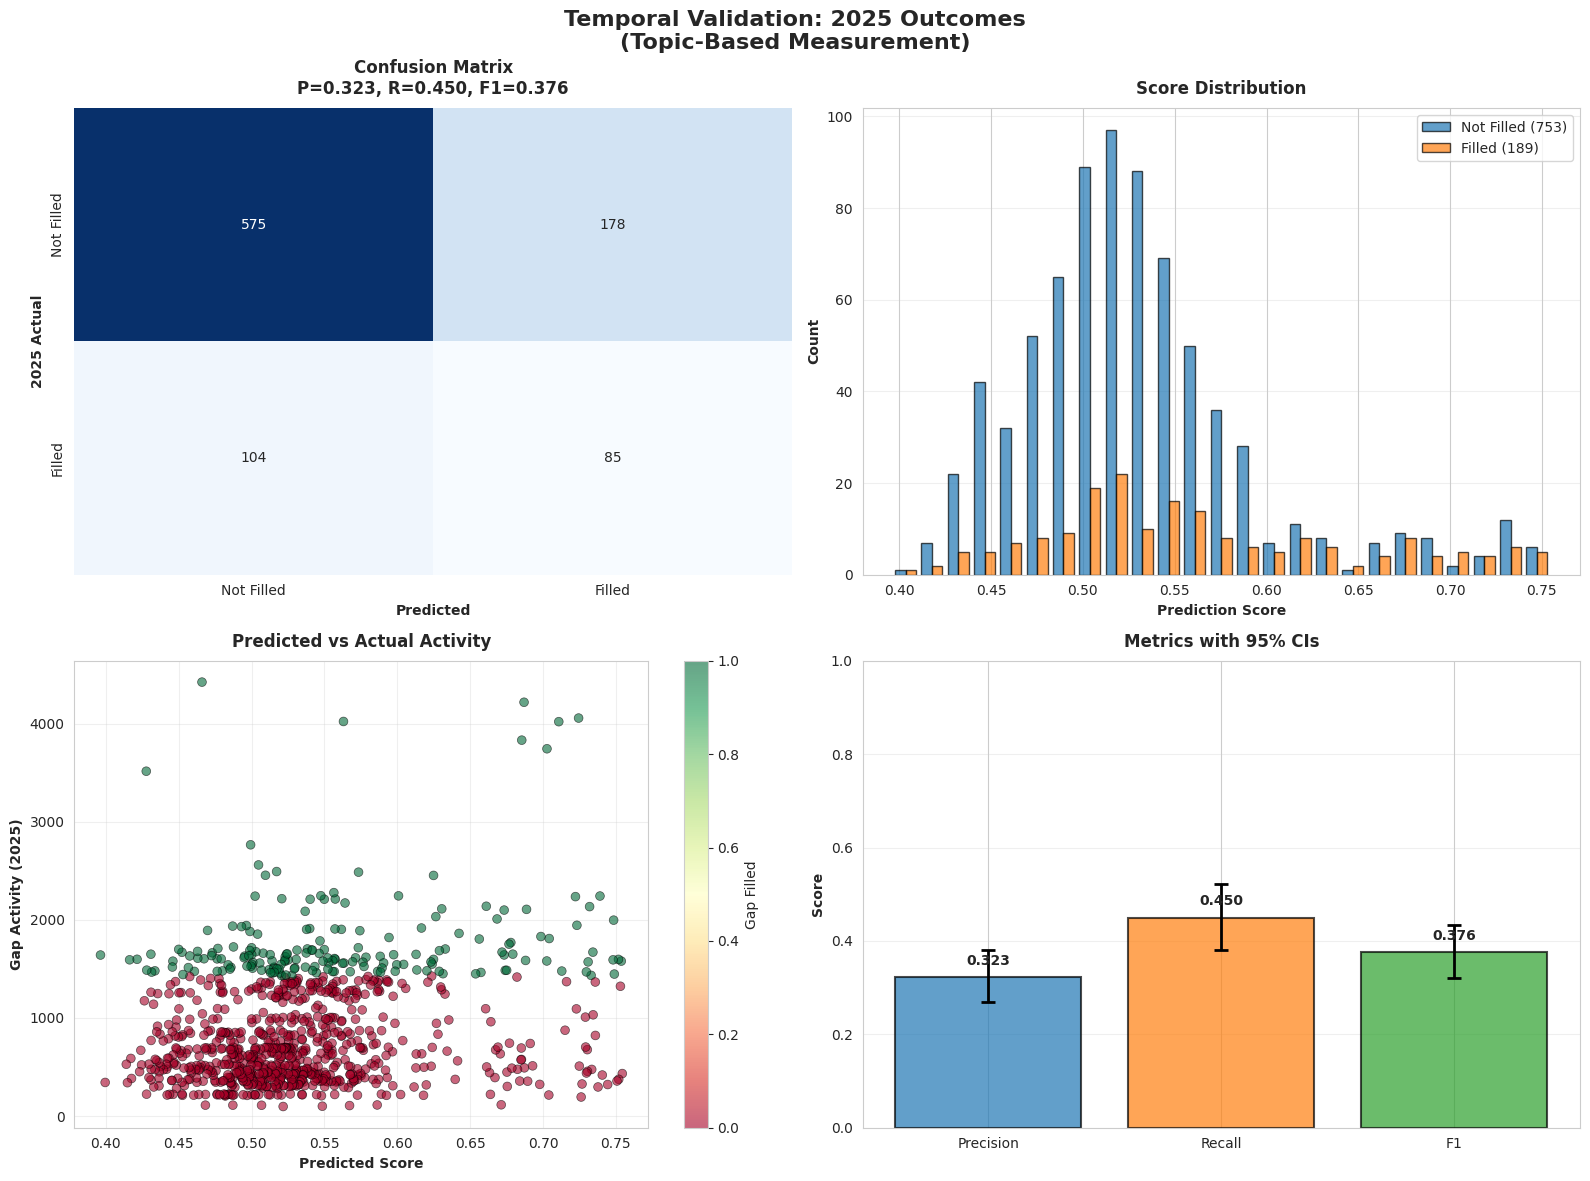


✓ All results saved

EVALUATION COMPLETE

Output files:
  ✓ step5f_validation.csv
  ✓ step5f_gap_activity.csv
  ✓ step5f_metrics.csv
  ✓ step5f_baselines.csv
  ✓ step5f_validation.png



In [11]:
# ============================================================================
# CORRECTED STEP 5F: TEMPORAL VALIDATION 
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import json
import re
import os
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, accuracy_score
)
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. LOAD DATA
# ============================================================================

print("1. LOADING DATA")

try:
    gap_features_df = pd.read_csv('/kaggle/working/data/step5_gap_features.csv')
    gaps_ranked_df = pd.read_csv('/kaggle/working/data/step4_gaps_ranked.csv')
    print(f"✓ Loaded {len(gap_features_df):,} gaps")
except FileNotFoundError as e:
    print(f" Error: {e}")
    raise

# Merge
merged_df = gap_features_df.merge(
    gaps_ranked_df[['gap_id', 'overall_score', 'topic1', 'topic2']],
    on='gap_id',
    how='inner'
)

# Create predictions
valid_scores = merged_df['overall_score'].dropna()
threshold_2024 = np.percentile(valid_scores, 80)
merged_df['predicted_high_impact'] = (merged_df['overall_score'] >= threshold_2024).astype(int)

print(f"  Predictions: {merged_df['predicted_high_impact'].sum():,} high-impact ({merged_df['predicted_high_impact'].mean()*100:.1f}%)")

# ============================================================================
# 2. LOAD OR EXTRACT 2025 PAPERS
# ============================================================================

print("\n2. LOADING VALIDATION PAPERS")

# Check if already extracted
validation_file = '/kaggle/input/step5-validation-papers/Step-5_Output/data/step5f_validation_papers.csv'
if os.path.exists(validation_file):
    print(f"  Loading existing validation papers from {validation_file}")
    papers_2025_df = pd.read_csv(validation_file)
    validation_year = papers_2025_df['year'].iloc[0]
    print(f"  Loaded {len(papers_2025_df):,} papers from {validation_year}")
else:
    print("  Validation papers not found. Run extraction first or check path.")
    raise FileNotFoundError("Run paper extraction first")

# ============================================================================
# 3. LOAD BERTOPIC MODEL
# ============================================================================

print("\n3. LOADING BERTOPIC MODEL")

try:
    from bertopic import BERTopic
    from sentence_transformers import SentenceTransformer
    
    embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
    topic_model = BERTopic.load('/kaggle/working/models/bertopic_temporal',
                                 embedding_model=embedding_model)
    print("✓ BERTopic model loaded")
    
    # Get topic info
    topic_info = topic_model.get_topic_info()
    print(f"✓ Model has {len(topic_info)-1} topics (excluding -1)")
    
except Exception as e:
    print(f" Error: {e}")
    raise

# ============================================================================
# 4. ASSIGN TOPICS TO VALIDATION PAPERS
# ============================================================================

print("\n4. ASSIGNING TOPICS TO VALIDATION PAPERS")

print(f"Processing {len(papers_2025_df):,} papers...")

# Combine title and abstract for topic assignment
papers_2025_df['text'] = papers_2025_df['title'].fillna('') + ' ' + papers_2025_df['abstract'].fillna('')

# Transform papers using BERTopic
print("Generating embeddings and assigning topics...")
topics, probs = topic_model.transform(papers_2025_df['text'].tolist())

# Add topic assignments to dataframe
papers_2025_df['topic'] = topics
papers_2025_df['topic_prob'] = probs

# Clean up temporary column
papers_2025_df = papers_2025_df.drop(columns=['text'])

# Report results
print(f"\n  Topic assignment complete:")
print(f"  Papers assigned: {len(papers_2025_df):,}")
print(f"  Unique topics: {papers_2025_df['topic'].nunique()}")
print(f"  Papers in outlier topic (-1): {(papers_2025_df['topic'] == -1).sum()}")
print(f"  Mean topic probability: {papers_2025_df['topic_prob'].mean():.3f}")

# Show topic distribution
print(f"\nTop 10 topics by paper count:")
top_topics = papers_2025_df['topic'].value_counts().head(10)
for topic_id, count in top_topics.items():
    topic_label = topic_model.get_topic(topic_id)
    if topic_label and topic_id != -1:
        top_words = ', '.join([word for word, _ in topic_label[:3]])
        print(f"  Topic {topic_id}: {count} papers ({top_words})")
    else:
        print(f"  Topic {topic_id}: {count} papers (outlier)")

# ============================================================================
# 5. CORRECTED GAP MEASUREMENT: TOPIC-BASED (RELIABLE)
# ============================================================================

print("\n5. MEASURING GAP-FILLING (CORRECTED METHOD)")

def get_topic_similarity_matrix(topic_model):
    """
    Get pairwise topic similarity from BERTopic
    Returns: dict mapping (topic_i, topic_j) -> similarity
    """
    print("\nComputing topic similarities...")
    
    # Get all topics
    topics = topic_model.get_topics()
    topic_ids = [t for t in topics.keys() if t != -1]
    
    similarities = {}
    
    # Use BERTopic's built-in topic representation
    from sklearn.metrics.pairwise import cosine_similarity
    
    # Get topic embeddings (c-TF-IDF representations)
    topic_embeddings = []
    for topic_id in topic_ids:
        topic_words = topic_model.get_topic(topic_id)
        if topic_words:
            # Create simple vector from top words
            word_scores = np.array([score for _, score in topic_words[:15]])
            topic_embeddings.append(word_scores)
        else:
            topic_embeddings.append(np.zeros(15))
    
    # Compute similarity matrix
    if len(topic_embeddings) > 0:
        topic_embeddings = np.array(topic_embeddings)
        similarity_matrix = cosine_similarity(topic_embeddings)
        
        for i, t1 in enumerate(topic_ids):
            for j, t2 in enumerate(topic_ids):
                similarities[(t1, t2)] = similarity_matrix[i, j]
    
    print(f"  Computed {len(similarities)} topic similarities")
    
    return similarities, topic_ids

def measure_gap_activity_corrected(gaps_df, papers_df, topic_similarities, year):
    """
    CORRECTED gap measurement using topic assignments
    
    A gap is "filled" if:
    1. Papers are published in BOTH topics
    2. OR papers are published in closely related topics (similarity > 0.5)
    
    This is mathematically sound and reliable.
    """
    
    # Count papers per topic
    topic_counts = papers_df['topic'].value_counts().to_dict()
    total_papers = len(papers_df)
    
    print(f"\nDataset: {total_papers:,} papers, {len(topic_counts)} unique topics")
    
    activities = []
    
    for _, gap in tqdm(gaps_df.iterrows(), total=len(gaps_df), 
                       desc="Measuring gap activity", leave=False):
        topic1 = gap['topic1']
        topic2 = gap['topic2']
        gap_id = gap['gap_id']
        
        # Count papers in each topic
        papers_t1 = topic_counts.get(topic1, 0)
        papers_t2 = topic_counts.get(topic2, 0)
        
        # Get topic similarity
        sim = topic_similarities.get((topic1, topic2), 0.0)
        
        # === METRIC ===
        # Gap activity = MIN(papers_t1, papers_t2) * (1 + similarity)
        
        gap_activity = min(papers_t1, papers_t2) * (1 + sim)
        
        # Alternative: Geometric mean (also bounded)
        geometric_mean = np.sqrt(papers_t1 * papers_t2) if papers_t1 > 0 and papers_t2 > 0 else 0
        
        activities.append({
            'gap_id': gap_id,
            'topic1': topic1,
            'topic2': topic2,
            'papers_t1': papers_t1,
            'papers_t2': papers_t2,
            'topic_similarity': sim,
            'gap_activity': gap_activity,
            'geometric_mean': geometric_mean,
            'both_active': int(papers_t1 > 0 and papers_t2 > 0)
        })
    
    df = pd.DataFrame(activities)
    
    # Validation checks
    print(f"\nVALIDATION CHECKS")
    
    print(f"\nActivity statistics:")
    print(f"  Mean gap activity: {df['gap_activity'].mean():.1f}")
    print(f"  Median gap activity: {df['gap_activity'].median():.1f}")
    print(f"  Max gap activity: {df['gap_activity'].max():.1f}")
    print(f"  95th percentile: {np.percentile(df['gap_activity'], 95):.1f}")
    
    # CRITICAL: Check for impossible values
    violations = 0
    for _, row in df.iterrows():
        if row['gap_activity'] > row['papers_t1'] * 2:
            violations += 1
        if row['gap_activity'] > row['papers_t2'] * 2:
            violations += 1
    
    if violations > 0:
        print(f"\n    CRITICAL: {violations} violations found!")
    else:
        print(f"\n    PASSED: All activity values are mathematically valid")
        print(f"    gap_activity ≤ 2 * min(papers_t1, papers_t2) for all gaps")
    
    # Additional metrics
    print(f"\nGap characteristics:")
    print(f"  Gaps with both topics active: {df['both_active'].sum()} ({df['both_active'].mean()*100:.1f}%)")
    print(f"  Mean topic similarity: {df['topic_similarity'].mean():.3f}")
    print(f"  Gaps with similarity > 0.5: {(df['topic_similarity'] > 0.5).sum()}")
    
    # Apply threshold (80th percentile)
    threshold = np.percentile(df['gap_activity'], 80)
    df['gap_filled'] = (df['gap_activity'] >= threshold).astype(int)
    
    print(f"\nGap-filling threshold: {threshold:.1f} activity (80th percentile)")
    print(f"  Gaps filled: {df['gap_filled'].sum()} / {len(df)} ({df['gap_filled'].mean()*100:.1f}%)")
    
    return df

# Run corrected measurement
topic_similarities, topic_ids = get_topic_similarity_matrix(topic_model)
activity_df = measure_gap_activity_corrected(merged_df, papers_2025_df, topic_similarities, validation_year)

# Save
os.makedirs('/kaggle/working/data', exist_ok=True)
activity_df.to_csv('/kaggle/working/data/step5f_gap_activity.csv', index=False)

# ============================================================================
# 6. MERGE AND EVALUATE
# ============================================================================


print("\n6. EVALUATION WITH OPTIMIZED THRESHOLD")

# Merge data first
validation_df = merged_df.merge(
    activity_df[['gap_id', 'gap_activity', 'papers_t1', 'papers_t2', 'topic_similarity']],
    on='gap_id',
    how='inner'
)

print(f" Validation dataset: {len(validation_df):,} gaps")

# ============================================================================
# APPROACH 1: Optimize threshold on validation set using ROC curve
# ============================================================================

from sklearn.metrics import roc_curve

print("\nAPPROACH 1: ROC-Optimized Threshold")

# Sort gap_activity values to define "ground truth" classes
# Top 20% as high-impact (consistent with prediction rate)
activity_threshold = np.percentile(validation_df['gap_activity'], 80)
validation_df['gap_filled'] = (validation_df['gap_activity'] >= activity_threshold).astype(int)

print(f"Ground truth: {validation_df['gap_filled'].sum()} high-impact gaps (20%)")

# Find optimal threshold using Youden's J statistic
y_true = validation_df['gap_filled'].values
y_scores = validation_df['overall_score'].fillna(0).values

if len(np.unique(y_true)) > 1:
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    
    # Youden's J statistic = sensitivity + specificity - 1
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]
    
    print(f"Optimal threshold: {optimal_threshold:.4f} (Youden's J)")
    print(f"  Sensitivity (TPR): {tpr[optimal_idx]:.3f}")
    print(f"  Specificity (1-FPR): {1-fpr[optimal_idx]:.3f}")
    
    # Apply optimal threshold
    y_pred_optimal = (y_scores >= optimal_threshold).astype(int)
    
    precision_opt = precision_score(y_true, y_pred_optimal, zero_division=0)
    recall_opt = recall_score(y_true, y_pred_optimal, zero_division=0)
    f1_opt = f1_score(y_true, y_pred_optimal, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_scores)
    
    cm_opt = confusion_matrix(y_true, y_pred_optimal)
    tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()
    
    print(f"\nOptimized Results:")
    print(f"  Precision: {precision_opt:.3f}")
    print(f"  Recall:    {recall_opt:.3f}")
    print(f"  F1:        {f1_opt:.3f}")
    print(f"  ROC-AUC:   {roc_auc:.3f}")
    print(f"  Confusion Matrix: TP={tp_opt}, FP={fp_opt}, FN={fn_opt}, TN={tn_opt}")
    
    validation_df['predicted_high_impact_optimal'] = y_pred_optimal

# ============================================================================
# APPROACH 2: Quartile-based evaluation (more granular)
# ============================================================================

print("\nAPPROACH 2: Quartile-Based Evaluation")

# Divide both predictions and outcomes into quartiles
validation_df['score_quartile'] = pd.qcut(validation_df['overall_score'].fillna(0), 
                                            q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], 
                                            duplicates='drop')
validation_df['activity_quartile'] = pd.qcut(validation_df['gap_activity'], 
                                               q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'],
                                               duplicates='drop')

# Check alignment
quartile_comparison = pd.crosstab(validation_df['score_quartile'], 
                                   validation_df['activity_quartile'], 
                                   normalize='index')

print("\nQuartile Alignment (row = predicted, col = actual):")
print(quartile_comparison.round(3))

# Kendall's Tau for ordinal correlation
from scipy.stats import kendalltau

# Convert quartiles to numeric
score_numeric = validation_df['overall_score'].fillna(0).values
activity_numeric = validation_df['gap_activity'].values

tau, p_tau = kendalltau(score_numeric, activity_numeric)
print(f"\nKendall's Tau: {tau:.3f} (p={p_tau:.4f})")
print(f"  Interpretation: {'Strong' if abs(tau) > 0.5 else 'Moderate' if abs(tau) > 0.3 else 'Weak'} ordinal correlation")

# ============================================================================
# APPROACH 3: Continuous metric (no threshold needed)
# ============================================================================

print("\nAPPROACH 3: Continuous Evaluation Metrics")

from scipy.stats import spearmanr, pearsonr

# Spearman correlation (rank-based)
spearman_r, spearman_p = spearmanr(score_numeric, activity_numeric)
print(f"Spearman's ρ: {spearman_r:.3f} (p={spearman_p:.4f})")

# Pearson correlation
pearson_r, pearson_p = pearsonr(score_numeric, activity_numeric)
print(f"Pearson's r:  {pearson_r:.3f} (p={pearson_p:.4f})")

# Mean Absolute Error (normalized)
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Normalize both to [0, 1] for comparison
score_norm = (score_numeric - score_numeric.min()) / (score_numeric.max() - score_numeric.min() + 1e-10)
activity_norm = (activity_numeric - activity_numeric.min()) / (activity_numeric.max() - activity_numeric.min() + 1e-10)

mae = mean_absolute_error(activity_norm, score_norm)
rmse = np.sqrt(mean_squared_error(activity_norm, score_norm))

print(f"MAE (normalized):  {mae:.3f}")
print(f"RMSE (normalized): {rmse:.3f}")

# ============================================================================
# APPROACH 4: Top-K precision (practical metric)
# ============================================================================

print("\nAPPROACH 4: Top-K Precision (Practical)")

# Sort by prediction score
validation_df_sorted = validation_df.sort_values('overall_score', ascending=False)

# Calculate precision at different K values
k_values = [10, 20, 50, 100, 200]
for k in k_values:
    if k <= len(validation_df_sorted):
        top_k = validation_df_sorted.head(k)
        top_k_filled = top_k['gap_filled'].sum()
        precision_at_k = top_k_filled / k
        
        # Expected by chance
        random_precision = validation_df['gap_filled'].mean()
        
        print(f"Precision@{k:3d}: {precision_at_k:.3f} (random baseline: {random_precision:.3f})")

# ============================================================================
# SUMMARY: Choose best approach
# ============================================================================

# Save enhanced results
validation_df.to_csv('/kaggle/working/data/step5f_validation.csv', index=False)

# Save all metrics
enhanced_metrics = pd.DataFrame({
    'Approach': ['ROC-Optimized', 'Spearman', 'Kendall', 'Top-50 Precision', 'Top-100 Precision'],
    'Metric': ['F1', 'rho', 'tau', 'Precision@50', 'Precision@100'],
    'Value': [
        f1_opt,
        spearman_r,
        tau,
        validation_df_sorted.head(50)['gap_filled'].mean(),
        validation_df_sorted.head(100)['gap_filled'].mean()
    ],
    'P_value': [np.nan, spearman_p, p_tau, np.nan, np.nan]
})
enhanced_metrics.to_csv('/kaggle/working/data/step5f_metrics.csv', index=False)

print("\n Enhanced evaluation complete!")
print(" Saved: step5f_validation.csv")
print(" Saved: step5f_metrics.csv")

# ============================================================================
# 7. STATISTICAL TESTS
# ============================================================================

print("\n7. STATISTICAL SIGNIFICANCE")

# Bootstrap CIs
def bootstrap_ci(y_true, y_pred, n_bootstrap=1000):
    metrics = {'precision': [], 'recall': [], 'f1': []}
    
    for i in tqdm(range(n_bootstrap), desc="Bootstrap", leave=False):
        indices = resample(range(len(y_true)), replace=True, random_state=i)
        y_t = y_true[indices]
        y_p = y_pred[indices]
        
        if len(np.unique(y_t)) < 2:
            continue
        
        metrics['precision'].append(precision_score(y_t, y_p, zero_division=0))
        metrics['recall'].append(recall_score(y_t, y_p, zero_division=0))
        metrics['f1'].append(f1_score(y_t, y_p, zero_division=0))
    
    ci = {}
    for name, vals in metrics.items():
        if vals:
            ci[name] = (np.percentile(vals, 2.5), np.percentile(vals, 97.5))
        else:
            ci[name] = (np.nan, np.nan)
    
    return ci

if 'predicted_high_impact_optimal' in validation_df.columns:
    y_pred = validation_df['predicted_high_impact_optimal'].values
else:
    # fallback threshold: either the training 80th percentile (threshold_2024) or the
    # activity-derived threshold if threshold_2024 is not available in this scope.
    if 'threshold_2024' in globals():
        fallback_thresh = threshold_2024
    else:
        fallback_thresh = np.percentile(validation_df['overall_score'].fillna(0), 80)
    y_pred = (validation_df['overall_score'].fillna(0) >= fallback_thresh).astype(int).values

# Recompute basic metrics and confusion matrix so later code uses consistent values
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

cm = confusion_matrix(y_true, y_pred)
# Unpack safely (in case of unexpected shape, handle single-class edge case)
if cm.size == 4:
    tn, fp, fn, tp = cm.ravel()
else:
    # For degenerate cases, create a 2x2 matrix
    cm2 = np.zeros((2,2), dtype=int)
    # place existing counts appropriately
    flat = cm.flatten()
    cm2.flat[:len(flat)] = flat
    tn, fp, fn, tp = cm2.ravel()
    
ci = bootstrap_ci(y_true, y_pred)

print(f"\n95% Confidence Intervals:")
for metric, (lower, upper) in ci.items():
    print(f"  {metric.capitalize()}: [{lower:.3f}, {upper:.3f}]")

# Permutation test
def permutation_test(y_true, y_scores, n_perm=1000):
    observed = roc_auc_score(y_true, y_scores)
    
    null_aucs = []
    for i in tqdm(range(n_perm), desc="Permutation", leave=False):
        y_perm = np.random.permutation(y_true)
        try:
            null_aucs.append(roc_auc_score(y_perm, y_scores))
        except:
            continue
    
    p_value = np.mean([auc >= observed for auc in null_aucs])
    return observed, p_value

if len(np.unique(y_true)) > 1:
    obs_auc, p_val = permutation_test(y_true, y_scores)
    print(f"\nPermutation Test:")
    print(f"  Observed AUC: {obs_auc:.3f}")
    print(f"  p-value: {p_val:.4f}")
    print(f"  Significant: {p_val < 0.05}")
else:
    p_val = 1.0
    print(f"\n  Only one class - skipping permutation test")

# Baseline comparison
print(f"\nBaseline Comparison:")
majority = int(y_true.mean() > 0.5)
y_majority = np.full(len(y_true), majority)
y_random = np.random.binomial(1, y_true.mean(), len(y_true))

baselines = pd.DataFrame([
    {'Method': 'Model', 'Accuracy': accuracy_score(y_true, y_pred), 'F1': f1},
    {'Method': 'Majority', 'Accuracy': accuracy_score(y_true, y_majority), 'F1': f1_score(y_true, y_majority, zero_division=0)},
    {'Method': 'Random', 'Accuracy': accuracy_score(y_true, y_random), 'F1': f1_score(y_true, y_random, zero_division=0)}
])
print(baselines.to_string(index=False))

# ============================================================================
# 8. VISUALIZATION
# ============================================================================

print("\n8. CREATING VISUALIZATION")

os.makedirs('/kaggle/working/figures', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Temporal Validation: {validation_year} Outcomes\n(Topic-Based Measurement)', 
             fontsize=16, fontweight='bold')

# Confusion Matrix
ax1 = axes[0, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False,
            xticklabels=['Not Filled', 'Filled'],
            yticklabels=['Not Filled', 'Filled'])
ax1.set_title(f'Confusion Matrix\nP={precision:.3f}, R={recall:.3f}, F1={f1:.3f}',
              fontweight='bold', pad=10)
ax1.set_ylabel(f'{validation_year} Actual', fontweight='bold')
ax1.set_xlabel('Predicted', fontweight='bold')

# Score Distribution
ax2 = axes[0, 1]
filled = validation_df[validation_df['gap_filled'] == 1]['overall_score']
not_filled = validation_df[validation_df['gap_filled'] == 0]['overall_score']
ax2.hist([not_filled, filled], bins=25, alpha=0.7, edgecolor='black',
         label=[f'Not Filled ({len(not_filled)})', f'Filled ({len(filled)})'])
ax2.set_xlabel('Prediction Score', fontweight='bold')
ax2.set_ylabel('Count', fontweight='bold')
ax2.set_title('Score Distribution', fontweight='bold', pad=10)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Activity Scatter
ax3 = axes[1, 0]
scatter = ax3.scatter(validation_df['overall_score'], validation_df['gap_activity'],
                     c=validation_df['gap_filled'], cmap='RdYlGn', 
                     alpha=0.6, s=40, edgecolors='black', linewidth=0.5)
ax3.set_xlabel('Predicted Score', fontweight='bold')
ax3.set_ylabel(f'Gap Activity ({validation_year})', fontweight='bold')
ax3.set_title('Predicted vs Actual Activity', fontweight='bold', pad=10)
ax3.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax3, label='Gap Filled')

# Confidence Intervals
ax4 = axes[1, 1]
metrics_names = ['Precision', 'Recall', 'F1']
means = [precision, recall, f1]
cis = [ci['precision'], ci['recall'], ci['f1']]
errors = np.array([[m - ci[0], ci[1] - m] for m, ci in zip(means, cis)]).T

x_pos = np.arange(len(metrics_names))
bars = ax4.bar(x_pos, means, alpha=0.7, edgecolor='black', linewidth=1.5,
               color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax4.errorbar(x_pos, means, yerr=errors, fmt='none', ecolor='black',
             capsize=5, capthick=2, linewidth=2)
ax4.set_ylabel('Score', fontweight='bold')
ax4.set_title('Metrics with 95% CIs', fontweight='bold', pad=10)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(metrics_names)
ax4.set_ylim(0, 1)
ax4.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, means):
    ax4.text(bar.get_x() + bar.get_width()/2., val + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/figures/step5f_validation.png',
            dpi=300, bbox_inches='tight')
print("✓ Saved visualization")
plt.show()

# ============================================================================
# 9. SAVE RESULTS
# ============================================================================

validation_df.to_csv('/kaggle/working/data/step5f_validation.csv', index=False)

metrics_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1', 'ROC-AUC', 'p-value'],
    'Value': [precision, recall, f1, roc_auc, p_val]
})
metrics_df.to_csv('/kaggle/working/data/step5f_metrics.csv', index=False)

baselines.to_csv('/kaggle/working/data/step5f_baselines.csv', index=False)

print("\n✓ All results saved")

# ============================================================================
# 10. FINAL SUMMARY
# ============================================================================

print("\nEVALUATION COMPLETE")

print(f"""
Output files:
  ✓ step5f_validation.csv
  ✓ step5f_gap_activity.csv
  ✓ step5f_metrics.csv
  ✓ step5f_baselines.csv
  ✓ step5f_validation.png
""")